# 1. Data Preparing

* 1.1 Import relevant packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy import stats
from pandas.plotting import scatter_matrix
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

sns.set(color_codes=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

* 1.2 Import the data and since the raw data has no title, they are imported with the names given to each column.

In [2]:
one = pd.read_csv(
    "./input/1.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
one.drop('Sequence', axis=1, inplace=True)

two = pd.read_csv(
    "./input/2.csv"
    ,names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
two.drop('Sequence', axis=1, inplace=True)

three = pd.read_csv(
    "./input/3.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
three.drop('Sequence', axis=1, inplace=True)

four = pd.read_csv(
    "./input/4.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
four.drop('Sequence', axis=1, inplace=True)

five = pd.read_csv(
    "./input/5.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
five.drop('Sequence', axis=1, inplace=True)

six = pd.read_csv(
    "./input/6.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
six.drop('Sequence', axis=1, inplace=True)

seven = pd.read_csv(
    "./input/7.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
seven.drop('Sequence', axis=1, inplace=True)

eight = pd.read_csv(
    "./input/8.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eight.drop('Sequence', axis=1, inplace=True)

nine = pd.read_csv(
    "./input/9.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
nine.drop('Sequence', axis=1, inplace=True)

ten = pd.read_csv(
    "./input/10.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
ten.drop('Sequence', axis=1, inplace=True)

eleven = pd.read_csv(
    "./input/11.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eleven.drop('Sequence', axis=1, inplace=True)

twelve = pd.read_csv(
    "./input/12.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
twelve.drop('Sequence', axis=1, inplace=True)

thirteen = pd.read_csv(
    "./input/13.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
thirteen.drop('Sequence', axis=1, inplace=True)

fourteen = pd.read_csv(
    "./input/14.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fourteen.drop('Sequence', axis=1, inplace=True)

fifteen = pd.read_csv(
    "./input/15.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fifteen.drop('Sequence', axis=1, inplace=True)

* 1.3 Add a new column called "Persn" and merge all the columns to a dataframe.

In [3]:
one['Person'] = 1
two['Person'] = 2
three['Person'] = 3
four['Person'] = 4
five['Person'] = 5
six['Person'] = 6
seven['Person'] = 7
eight['Person'] = 8
nine['Person'] = 9
ten['Person'] = 10
eleven['Person'] = 11
twelve['Person'] = 12
thirteen['Person'] = 13
fourteen['Person'] = 14
fifteen['Person'] = 15   #15 Participants and 7 Activities


frames = [one, two, three, four, five, six, seven, eight, nine, ten, eleven, twelve, thirteen, fourteen, fifteen]
df = pd.concat(frames)   
print(df.shape)  
print(df.head())

(1926896, 5)
   x_acceleration  y_acceleration  z_acceleration  Labels  Person
0            1502            2215            2153       1       1
1            1667            2072            2047       1       1
2            1611            1957            1906       1       1
3            1601            1939            1831       1       1
4            1643            1965            1879       1       1


* 1.4 Due to the large amount of sample data, we choose to sample randomly.And then we know briefly the basic information of the data set.

In [4]:
df_rnd = df.sample(n=100000, random_state=6758)  # Sampling randomly according to a certain number 

df_rnd_2 = df.sample(frac=0.5)
print(df_rnd_2.shape)                            # Sampling randomly according to a certain scale 

(963448, 5)


In [5]:
df_rnd = df_rnd[df_rnd['Labels'] != 0]  # There are only seven categories in the actual problem, so we remove data which are labeled 0.
print(df_rnd.shape)
print(df_rnd['Labels'].value_counts())

(99819, 5)
Labels
1    31627
7    30770
4    18590
3    11178
5     2785
2     2498
6     2371
Name: count, dtype: int64


In [6]:
print(df_rnd.dtypes, df_rnd.isna().sum())
print(df_rnd.describe())

print(df_rnd.groupby('Labels').mean())  

x_acceleration    int64
y_acceleration    int64
z_acceleration    int64
Labels            int64
Person            int64
dtype: object x_acceleration    0
y_acceleration    0
z_acceleration    0
Labels            0
Person            0
dtype: int64
       x_acceleration  y_acceleration  z_acceleration        Labels  \
count    99819.000000    99819.000000    99819.000000  99819.000000   
mean      1987.307336     2381.967471     1970.829041      3.887617   
std        111.369988      100.211564       94.573223      2.438922   
min        483.000000       74.000000     1157.000000      1.000000   
25%       1904.000000     2337.000000     1918.000000      1.000000   
50%       1991.000000     2366.000000     1988.000000      4.000000   
75%       2076.000000     2411.000000     2033.000000      7.000000   
max       2895.000000     2968.000000     4095.000000      7.000000   

             Person  
count  99819.000000  
mean       7.518589  
std        4.185780  
min        1.000000  
25%

From the above means,it seems that y_acceleration always keeps biggest regardless of seven activities.In addition, x_acceleration's maximum is label 5 and label 6 , namely "Going UpDown Stairs"and " Walking and Talking with Someone", y_acceleration's minimun is label 2, namely"Standing Up, Walking and Going updown stairs", z_acceleration's maximum is label 5, namely "Going UpDown Stairs".

# 2. Data Exploring

* 2.1 Explore relationships between attributes and visualization.

/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_8454/136514995.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],


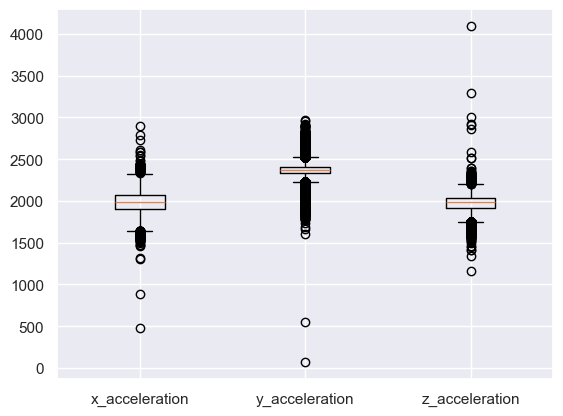

In [7]:
plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

    x_acceleration  y_acceleration  z_acceleration  Labels  Person
84            1670            2147            2079       1       1
88            1726            2203            2005       1       1
89            1778            2143            1946       1       1
90            1718            2102            2012       1       1
93            1664            2241            2064       1       1


/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_8454/3561576925.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],


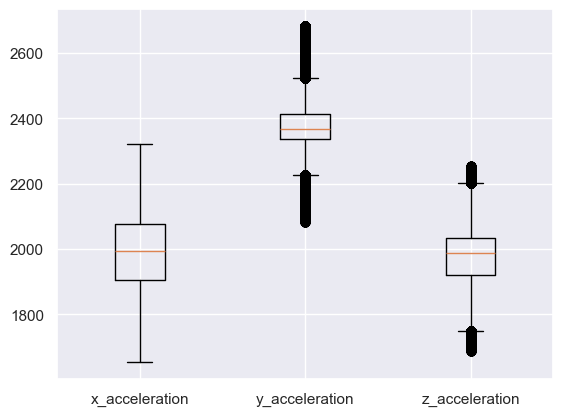

In [8]:
temp = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]  
print(temp.head())
plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

The boxplot of non-outliers for data according to zscore.

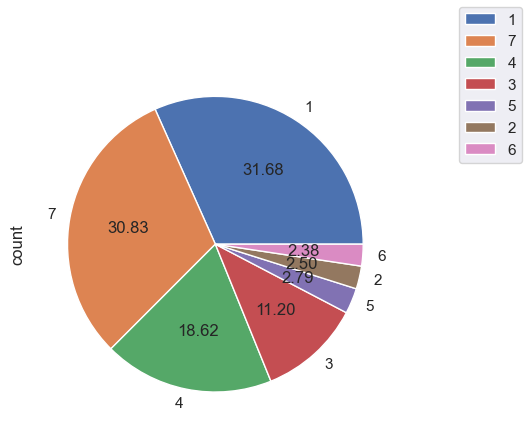

In [9]:
df_rnd['Labels'].value_counts().plot(kind='pie', autopct='%.2f')  
plt.figlegend()  
plt.show()  

According to the pie chart, it can be determined that Label 1, 4 and 7 account for the largest proportion, namely Working at Computer, Walking, Talking while Standing respectively.

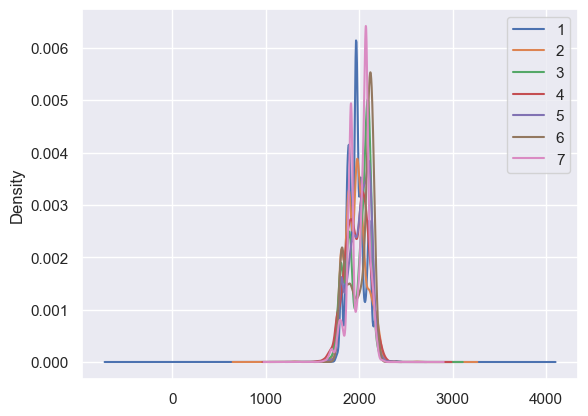

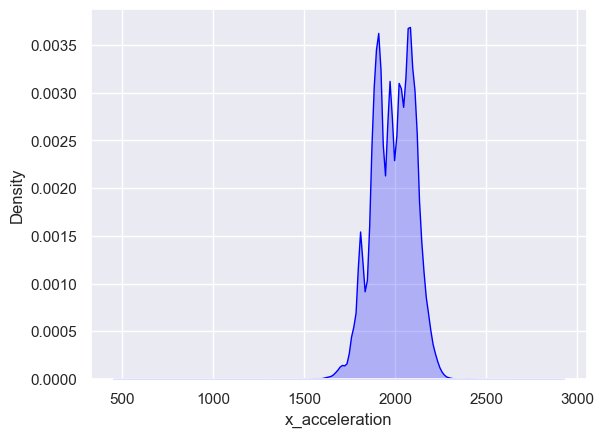

In [10]:
df_rnd.groupby('Labels')['x_acceleration'].plot.kde()   
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["x_acceleration"], fill=True, color='blue')
plt.show()

According to the kernel density,we can know that x_acceleration is between 1600 and 2300.In addition, label 7 and label 1 have the highest probability,namely Talking while Standing and Working at Computer respectively.

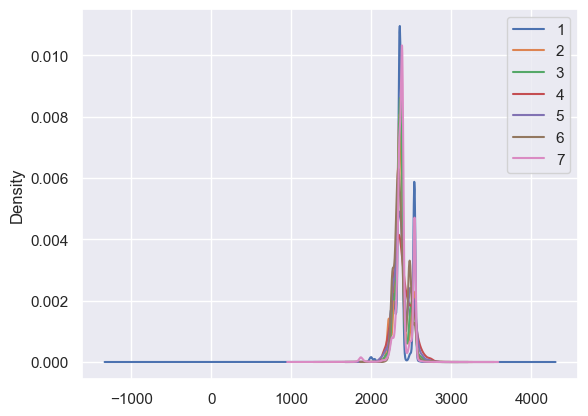

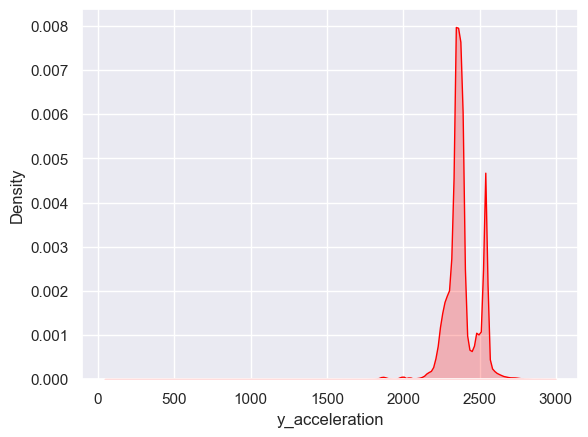

In [11]:
df_rnd.groupby('Labels')['y_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["y_acceleration"], fill=True, color='red')
plt.show()

According to the kernel density,we can know that y_acceleration is between 2200 and 2800.In addition, label 1 and label 7 have the highest probability,namely Working at Computer  and Talking while Standing respectively.

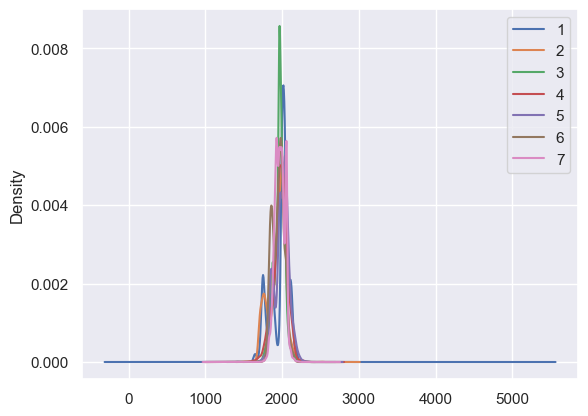

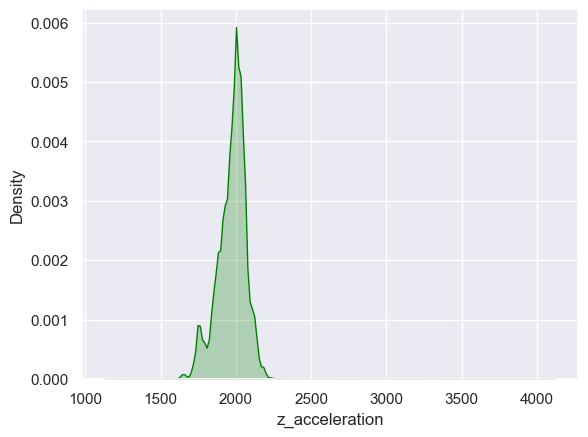

In [12]:
df_rnd.groupby('Labels')['z_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["z_acceleration"], fill=True, color='green')
plt.show()

According to the kernel density,we can know that z_acceleration is between 1600 and 2300.In addition, label 3 and label 1 have the highest probability, namely Standing and Working at Computer respectively.

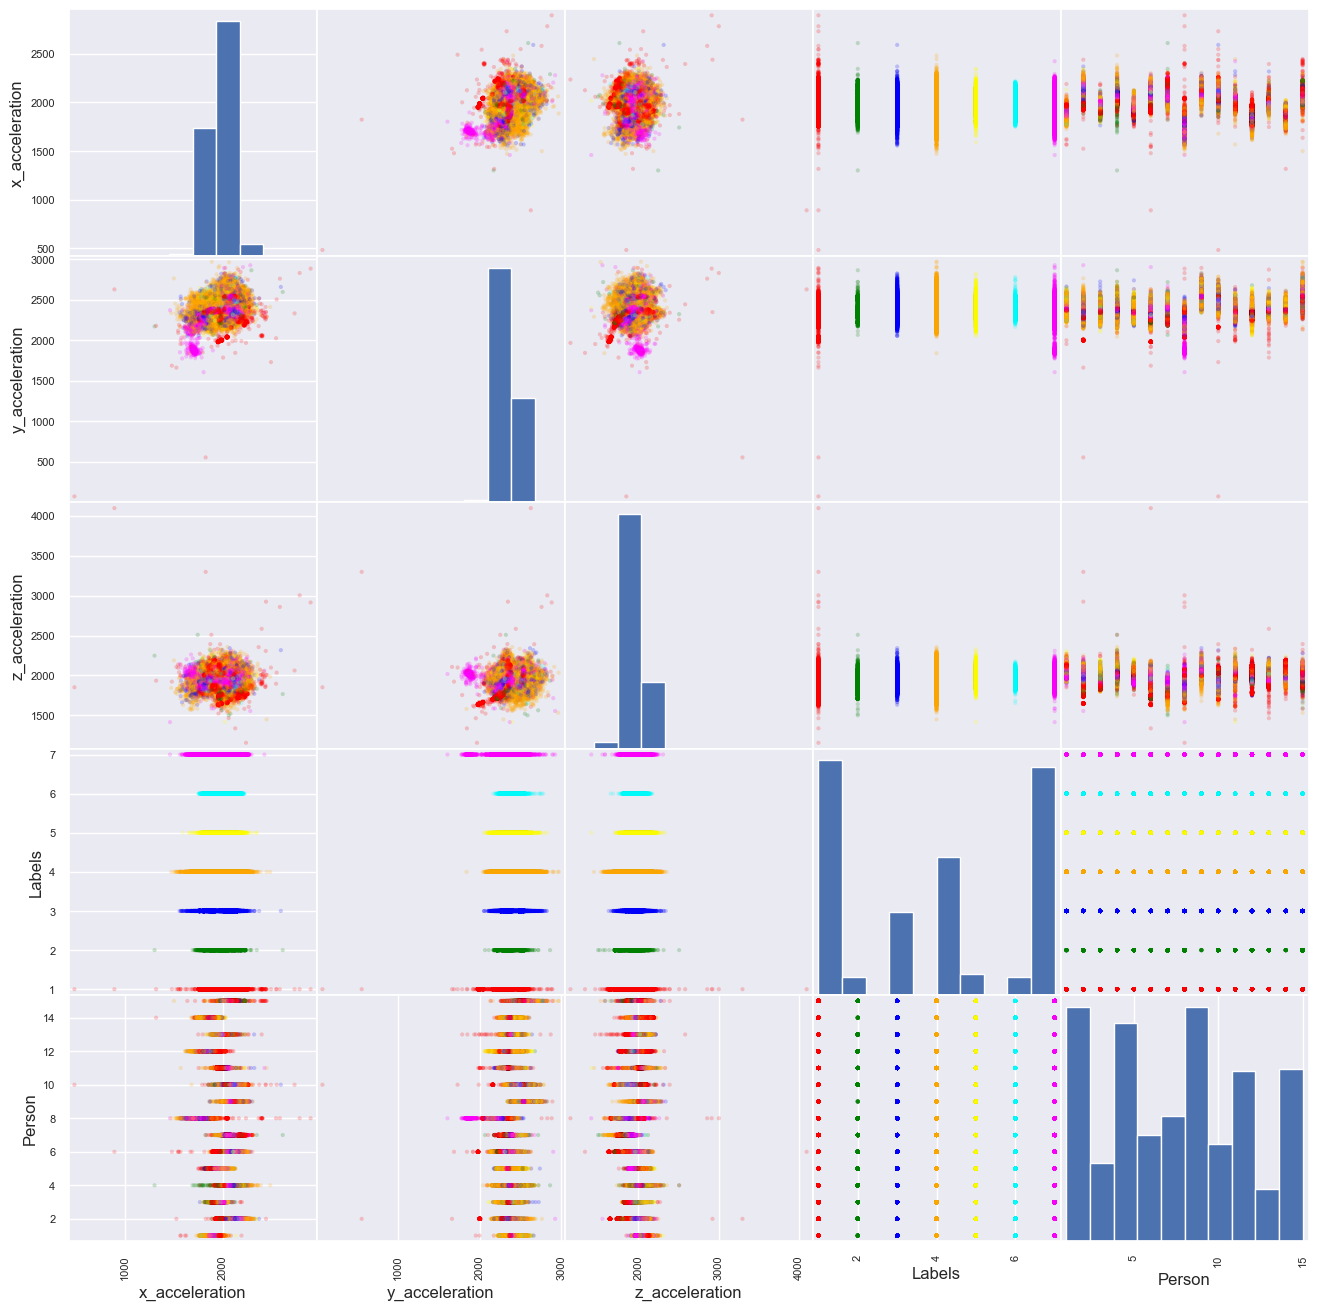

In [13]:
colors_palette = {1: 'red', 2: 'green', 3: 'blue', 4: 'orange', 5: 'yellow', 6: 'cyan', 7: 'magenta'}
colors = [colors_palette[c] for c in df_rnd['Labels']]
scatter_matrix(df_rnd, alpha=0.2, figsize=(16, 16), diagonal='hist', c=colors)
plt.show()

                x_acceleration  y_acceleration  z_acceleration    Labels  \
x_acceleration        1.000000        0.371044        0.015191  0.079724   
y_acceleration        0.371044        1.000000        0.340963  0.044100   
z_acceleration        0.015191        0.340963        1.000000  0.030303   
Labels                0.079724        0.044100        0.030303  1.000000   
Person               -0.018510        0.284180        0.127364 -0.174606   

                  Person  
x_acceleration -0.018510  
y_acceleration  0.284180  
z_acceleration  0.127364  
Labels         -0.174606  
Person          1.000000  


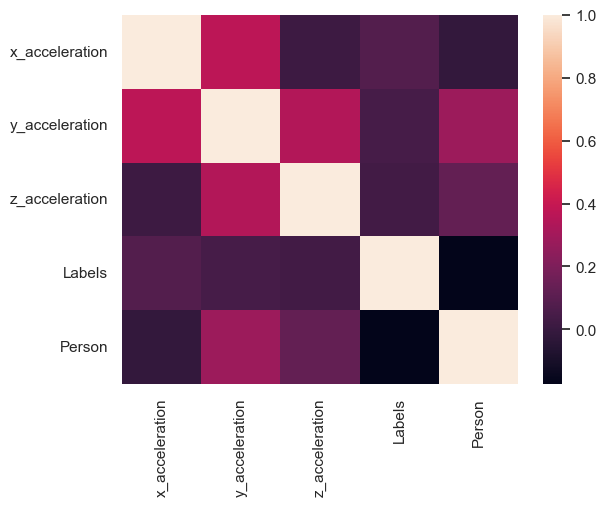

In [14]:
print(df_rnd.corr(method='pearson'))

sns.heatmap(df_rnd.corr(method='pearson'))
plt.show()

We can know the correlation between those attributes according the scatter_matrix figure and heatmap.Correlations between the accelerations are close to 0.5, however, between the accalerations and labels are close to 0.1 merely.

# 3. Data Modeling 

* 3.1 Identify factors and response, data encoding, data normalization and standardization, and divide the data into training set and testing set.

In [15]:
label_names = {
    1: "Working at Computer",
    2: "Standing Up, Walking, Going Up/Down Stairs",
    3: "Standing",
    4: "Walking",
    5: "Going Up/Down Stairs",
    6: "Walking and Talking with Someone",
    7: "Talking while Standing"
}

def plot_activity_windows(
    person_id,
    offset_seconds=0,
    window_seconds=5,
    fs=52,
    base_path="./input",
    labels=None,
    drop_label_0=True,
    center_signal=False,
    figsize=(12, 4)
):
    file_path = f"{base_path}/{person_id}.csv"

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].reset_index(drop=True)

    window_size = int(window_seconds * fs)
    offset_samples = int(offset_seconds * fs)

    if labels is None:
        labels = sorted(df["Labels"].unique())

    def get_contiguous_window_with_offset(df, label, window_size, offset_samples):
        idx = df.index[df["Labels"] == label].to_numpy()
        if len(idx) == 0:
            return None

        breaks = np.where(np.diff(idx) != 1)[0] + 1
        runs = np.split(idx, breaks)

        for run in runs:
            if len(run) >= offset_samples + window_size:
                start = run[0] + offset_samples
                end = start + window_size
                return df.loc[start:end - 1].copy()

        return None

    for label in labels:
        segment = get_contiguous_window_with_offset(
            df=df,
            label=label,
            window_size=window_size,
            offset_samples=offset_samples
        )

        if segment is None:
            print(
                f"Skipping label {label}: no contiguous window long enough for "
                f"offset={offset_seconds}s and window={window_seconds}s."
            )
            continue

        plot_df = segment[["x_acceleration", "y_acceleration", "z_acceleration"]].copy()

        if center_signal:
            plot_df = plot_df - plot_df.mean()

        t = np.arange(len(segment)) / fs

        plt.figure(figsize=figsize)
        plt.plot(t, plot_df["x_acceleration"], label="x_acceleration")
        plt.plot(t, plot_df["y_acceleration"], label="y_acceleration")
        plt.plot(t, plot_df["z_acceleration"], label="z_acceleration")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Acceleration")
        plt.title(
            f"Person {person_id}, Label {label}: {label_names.get(label, str(label))}\n"
            f"Offset={offset_seconds}s, Window={window_seconds}s"
        )
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

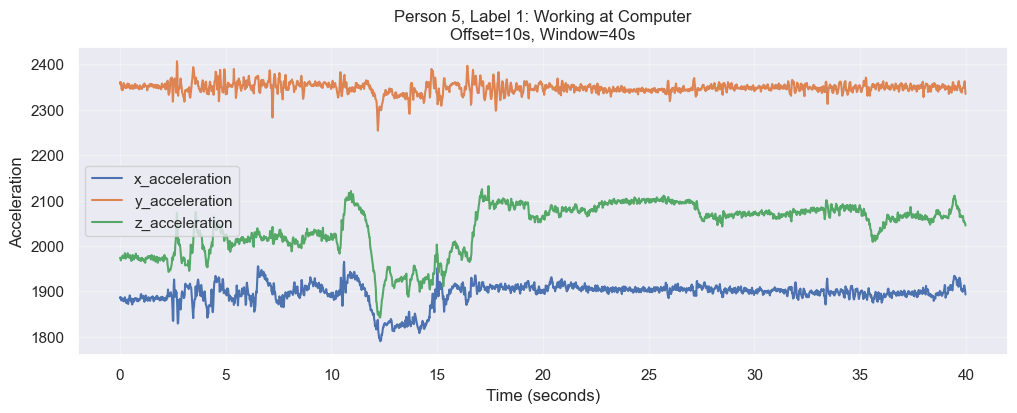

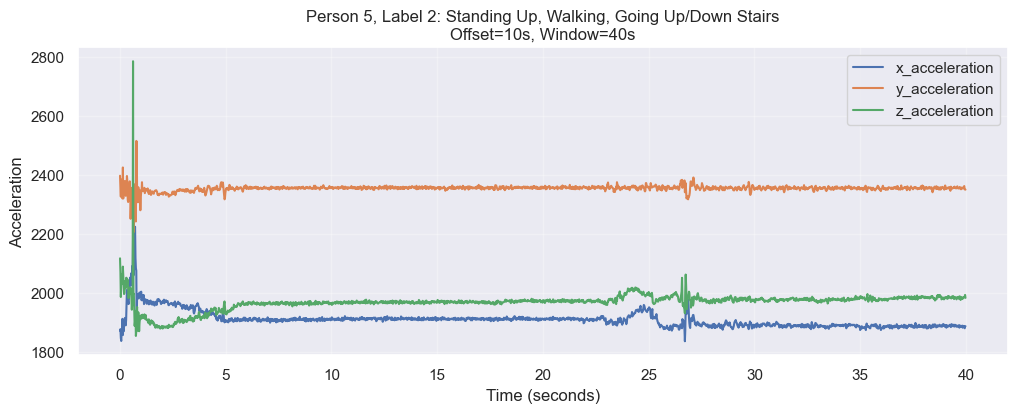

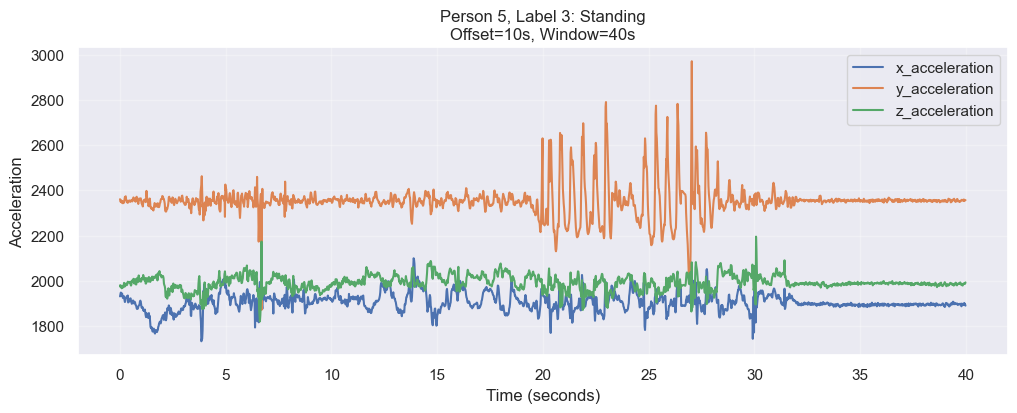

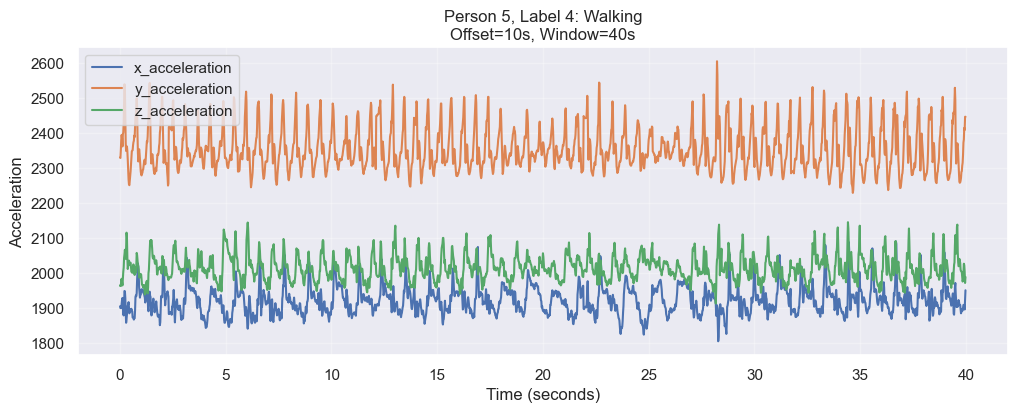

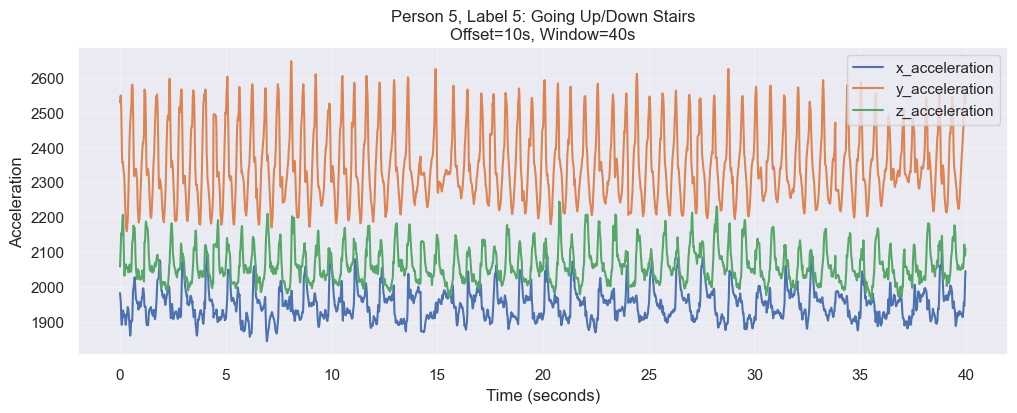

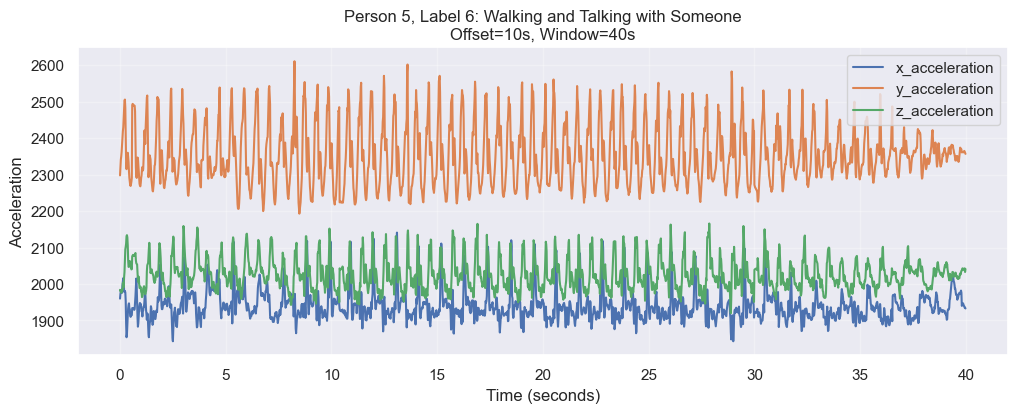

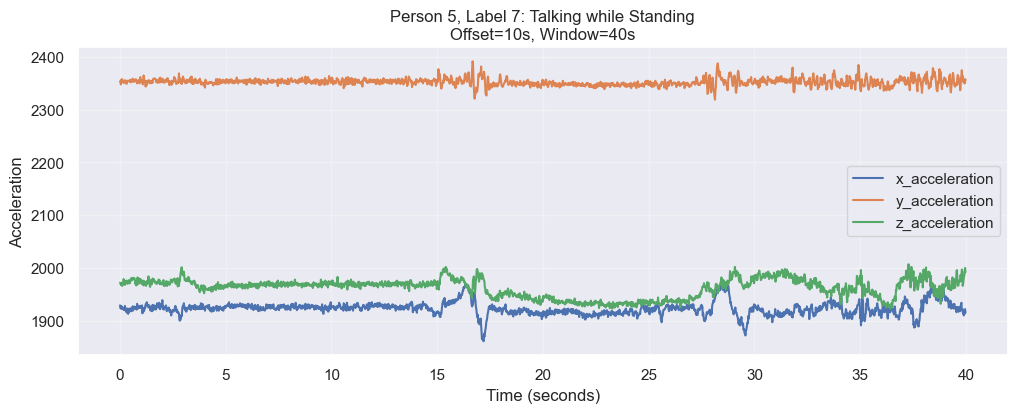

In [16]:
plot_activity_windows(
    person_id=5,
    offset_seconds=10,
    window_seconds=40
)

In [17]:
def compare_centering_methods(
    person_id,
    label=None,
    offset_seconds=0,
    window_seconds=10,
    fs=52,
    base_path="./input",
    local_window_seconds=2.0,
    figsize=(14, 8)
):
    """
    Compare global vs local mean centering on x/y/z signals.

    Produces two plots:
    1. Global mean centered (true centering)
    2. Local rolling mean centered (high-pass filtered)
    """

    # Load data
    df = pd.read_csv(
        f"{base_path}/{person_id}.csv",
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    df = df[df["Labels"] != 0].reset_index(drop=True)

    # Filter label if requested
    if label is not None:
        df = df[df["Labels"] == label].reset_index(drop=True)

    # Window selection
    start = int(offset_seconds * fs)
    n = int(window_seconds * fs)
    end = start + n

    if end > len(df):
        print("Window exceeds available data.")
        return

    segment = df.iloc[start:end].copy()
    xyz = segment[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float)

    # ---- GLOBAL MEAN ----
    xyz_global = xyz - xyz.mean()

    # ---- LOCAL MEAN ----
    w = max(3, int(local_window_seconds * fs))
    local_mean = xyz.rolling(window=w, center=True, min_periods=1).mean()
    xyz_local = xyz - local_mean

    # Time axis
    t = np.arange(len(xyz)) / fs

    # ---- PLOT GLOBAL ----
    plt.figure(figsize=figsize)

    plt.subplot(2, 1, 1)
    plt.plot(t, xyz_global["x_acceleration"], label="x")
    plt.plot(t, xyz_global["y_acceleration"], label="y")
    plt.plot(t, xyz_global["z_acceleration"], label="z")
    plt.axhline(0, linestyle="--")
    plt.title("Global Mean Centering (true centering)")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.grid(alpha=0.3)

    # ---- PLOT LOCAL ----
    plt.subplot(2, 1, 2)
    plt.plot(t, xyz_local["x_acceleration"], label="x")
    plt.plot(t, xyz_local["y_acceleration"], label="y")
    plt.plot(t, xyz_local["z_acceleration"], label="z")
    plt.axhline(0, linestyle="--")
    plt.title(f"Local Mean Centering ({local_window_seconds}s window, high-pass effect)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.suptitle(
        f"Person {person_id}" +
        (f", Label {label}" if label is not None else "") +
        f"\nOffset={offset_seconds}s, Window={window_seconds}s"
    )

    plt.tight_layout()
    plt.show()

    # Print stats for sanity
    print("\nMeans after centering:")
    print("Global:\n", xyz_global.mean())
    print("\nLocal:\n", xyz_local.mean())

    return {
        "raw": xyz,
        "global": xyz_global,
        "local": xyz_local
    }

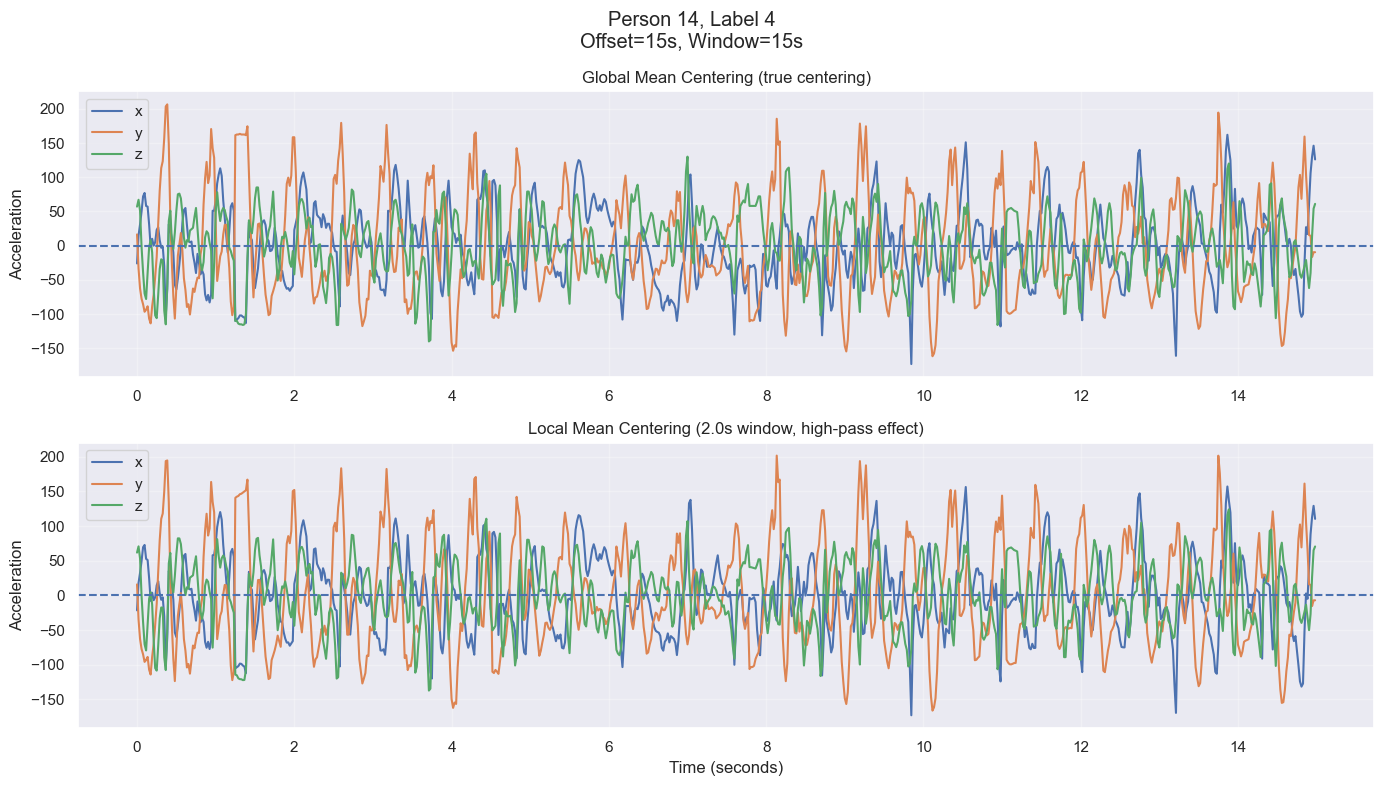


Means after centering:
Global:
 x_acceleration    3.964464e-14
y_acceleration    3.731260e-14
z_acceleration    5.013881e-14
dtype: float64

Local:
 x_acceleration    0.019774
y_acceleration   -0.252626
z_acceleration   -0.157138
dtype: float64


{'raw':       x_acceleration  y_acceleration  z_acceleration
 780           1819.0          2389.0          2030.0
 781           1860.0          2339.0          2040.0
 782           1876.0          2310.0          2024.0
 783           1895.0          2295.0          1971.0
 784           1917.0          2287.0          1934.0
 785           1922.0          2276.0          1903.0
 786           1903.0          2279.0          1895.0
 787           1902.0          2284.0          1934.0
 788           1876.0          2266.0          1971.0
 789           1843.0          2259.0          1981.0
 790           1855.0          2284.0          1963.0
 791           1845.0          2301.0          1911.0
 792           1850.0          2327.0          1871.0
 793           1868.0          2356.0          1867.0
 794           1872.0          2405.0          1901.0
 795           1853.0          2453.0          1939.0
 796           1842.0          2486.0          1953.0
 797           1844.0

In [18]:
compare_centering_methods(
    person_id=14,
    label=4,
    offset_seconds=15,
    window_seconds=15
)

In [19]:


def plot_zero_centered_motion_with_sample_ma(
    person_id,
    label=None,
    offset_seconds=0,
    window_seconds=10,
    fs=52,
    base_path="./input",
    axis_center_window_samples=104,
    motion_center_window_samples=104,
    smoothing_samples=(5, 26, 52),
    drop_label_0=True,
    figsize=(14, 5)
):
    """
    Plot motion signal centered around zero by:
    1. subtracting a rolling mean from each axis
    2. computing motion magnitude
    3. subtracting a rolling mean from the magnitude itself
    4. overlaying moving averages
    """

    file_path = f"{base_path}/{person_id}.csv"

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    if label is not None:
        df = df[df["Labels"] == label].copy()

    df = df.reset_index(drop=True)

    start = int(offset_seconds * fs)
    n = int(window_seconds * fs)
    end = start + n

    if end > len(df):
        print("Requested segment exceeds available data.")
        return None

    segment = df.iloc[start:end].copy()
    xyz = segment[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float)

    # Step 1: local centering of x/y/z
    axis_n = max(3, int(axis_center_window_samples))
    axis_mean = xyz.rolling(window=axis_n, center=True, min_periods=1).mean()
    xyz_centered = xyz - axis_mean

    # Step 2: motion magnitude
    motion = np.sqrt((xyz_centered ** 2).sum(axis=1))

    # Step 3: rolling-mean removal on motion itself
    motion_n = max(3, int(motion_center_window_samples))
    motion_baseline = pd.Series(motion).rolling(
        window=motion_n,
        center=True,
        min_periods=1
    ).mean()

    motion_zero = motion - motion_baseline

    t = np.arange(len(segment)) / fs

    plt.figure(figsize=figsize)
    plt.plot(t, motion_zero, alpha=0.35, label="motion zero-centered")

    for s in smoothing_samples:
        smooth_n = max(1, int(s))
        motion_smooth = pd.Series(motion_zero).rolling(
            window=smooth_n,
            center=True,
            min_periods=1
        ).mean()
        plt.plot(t, motion_smooth, label=f"MA {s} samples")

    plt.axhline(0, linestyle=":")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Zero-centered motion")
    plt.title(
        f"Person {person_id}" +
        (f", Label {label}" if label is not None else "") +
        f"\naxis center={axis_n} samples, motion center={motion_n} samples"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Mean of zero-centered motion:", float(np.mean(motion_zero)))

    return {
        "segment": segment,
        "xyz_centered": xyz_centered,
        "motion": motion,
        "motion_zero": motion_zero,
        "time": t
    }

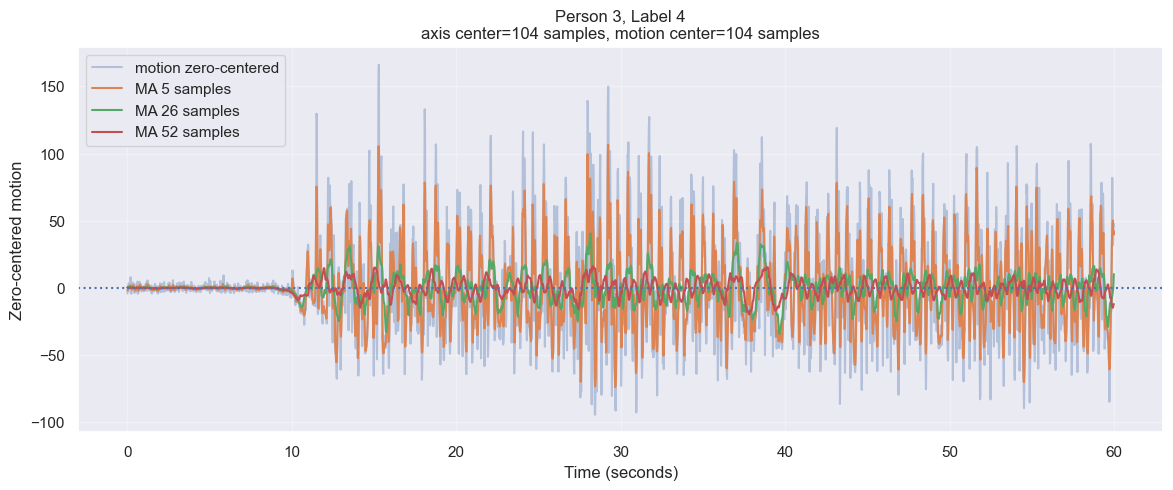

Mean of zero-centered motion: 0.004184631051525364


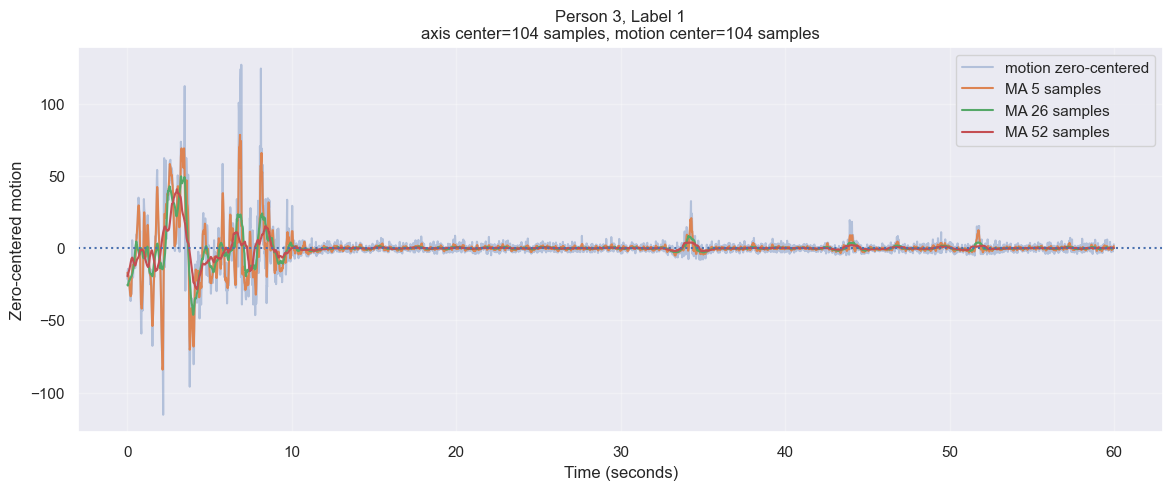

Mean of zero-centered motion: -0.06594879059270264


{'segment':       Sequence  x_acceleration  y_acceleration  z_acceleration  Labels
 0          0.0            1928            2382            1943       1
 1          1.0            1920            2375            1944       1
 2          2.0            1919            2374            1942       1
 3          3.0            1923            2382            1949       1
 4          4.0            1921            2374            1949       1
 5          5.0            1924            2376            1942       1
 6          6.0            1922            2371            1950       1
 7          7.0            1924            2377            1950       1
 8          8.0            1928            2381            1951       1
 9          9.0            1926            2374            1955       1
 10        10.0            1928            2378            1954       1
 11        11.0            1945            2375            1943       1
 12        12.0            1958            2381      

In [20]:
plot_zero_centered_motion_with_sample_ma(
    person_id=3,
    label=4,
    offset_seconds=0,
    window_seconds=60,
    axis_center_window_samples=104,
    motion_center_window_samples=104,
    smoothing_samples=(5, 26, 52)
)
plot_zero_centered_motion_with_sample_ma(
    person_id=3,
    label=1,
    offset_seconds=0,
    window_seconds=60,
    axis_center_window_samples=104,
    motion_center_window_samples=104,
    smoothing_samples=(5, 26, 52)
)


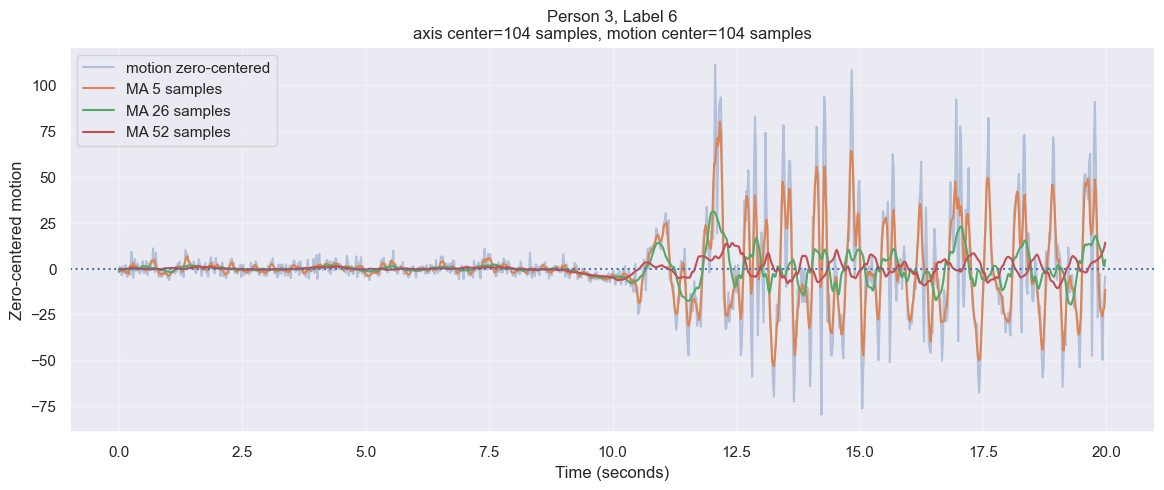

Mean of zero-centered motion: 0.0804750669195891


{'segment':       Sequence  x_acceleration  y_acceleration  z_acceleration  Labels
 0      80000.0            1969            2386            1964       6
 1      80001.0            1972            2386            1970       6
 2      80002.0            1972            2383            1966       6
 3      80003.0            1967            2385            1965       6
 4      80004.0            1967            2387            1960       6
 5      80005.0            1970            2381            1966       6
 6      80006.0            1969            2385            1964       6
 7      80007.0            1967            2376            1970       6
 8      80008.0            1969            2383            1967       6
 9      80009.0            1967            2382            1965       6
 10     80010.0            1971            2382            1968       6
 11     80011.0            1967            2383            1962       6
 12     80012.0            1965            2385      

In [21]:
plot_zero_centered_motion_with_sample_ma(
    person_id=3,
    label=6,
    offset_seconds=0,
    window_seconds=20,
    axis_center_window_samples=104,
    motion_center_window_samples=104,
    smoothing_samples=(5, 26, 52)
)

In [22]:
def plot_xyz_with_multiple_smoothing(
    person_id,
    label=None,
    offset_seconds=0,
    window_seconds=10,
    fs=52,
    base_path="./input",
    local_center_window_seconds=2.0,
    smoothing_seconds=(0.2, 0.8, 2.0),
    drop_label_0=True,
    figsize=(14, 6)
):
    file_path = f"{base_path}/{person_id}.csv"

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    if label is not None:
        df = df[df["Labels"] == label].copy()

    df = df.reset_index(drop=True)

    start = int(offset_seconds * fs)
    n = int(window_seconds * fs)
    end = start + n

    if end > len(df):
        print("Requested segment exceeds available data.")
        return None

    segment = df.iloc[start:end].copy()
    xyz = segment[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float)

    # Local centering per axis
    local_n = max(3, int(local_center_window_seconds * fs))
    local_mean = xyz.rolling(window=local_n, center=True, min_periods=1).mean()
    xyz_centered = xyz - local_mean

    t = np.arange(len(segment)) / fs

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    axis_names = ["x_acceleration", "y_acceleration", "z_acceleration"]

    for ax, col in zip(axes, axis_names):
        ax.plot(t, xyz_centered[col], alpha=0.35, label=f"{col} raw centered")

        for s in smoothing_seconds:
            smooth_n = max(1, int(s * fs))
            smooth_signal = xyz_centered[col].rolling(
                window=smooth_n,
                center=True,
                min_periods=1
            ).mean()
            ax.plot(t, smooth_signal, label=f"MA {s}s")

        ax.axhline(0, linestyle=":")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)
        ax.legend()

    title = f"Person {person_id}"
    if label is not None:
        title += f", Label {label}"
    title += (
        f"\nLocally centered per axis, offset={offset_seconds}s, "
        f"window={window_seconds}s, local centering={local_center_window_seconds}s"
    )

    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout()
    plt.show()

    return {
        "segment": segment,
        "xyz_centered": xyz_centered,
        "time": t
    }

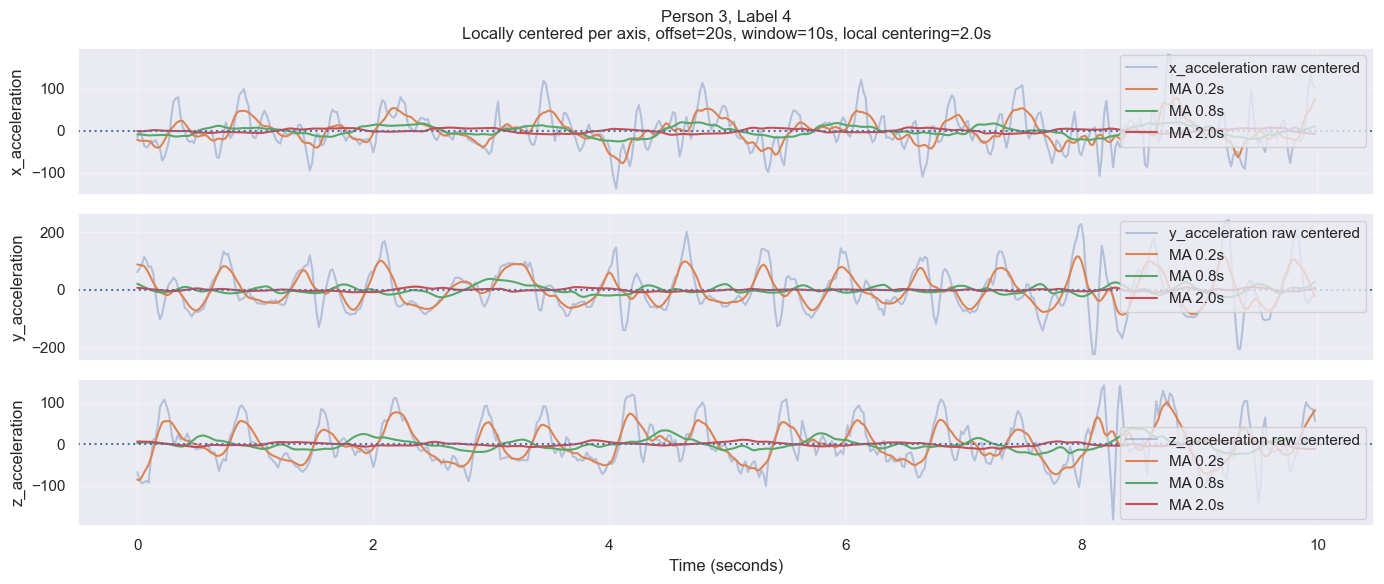

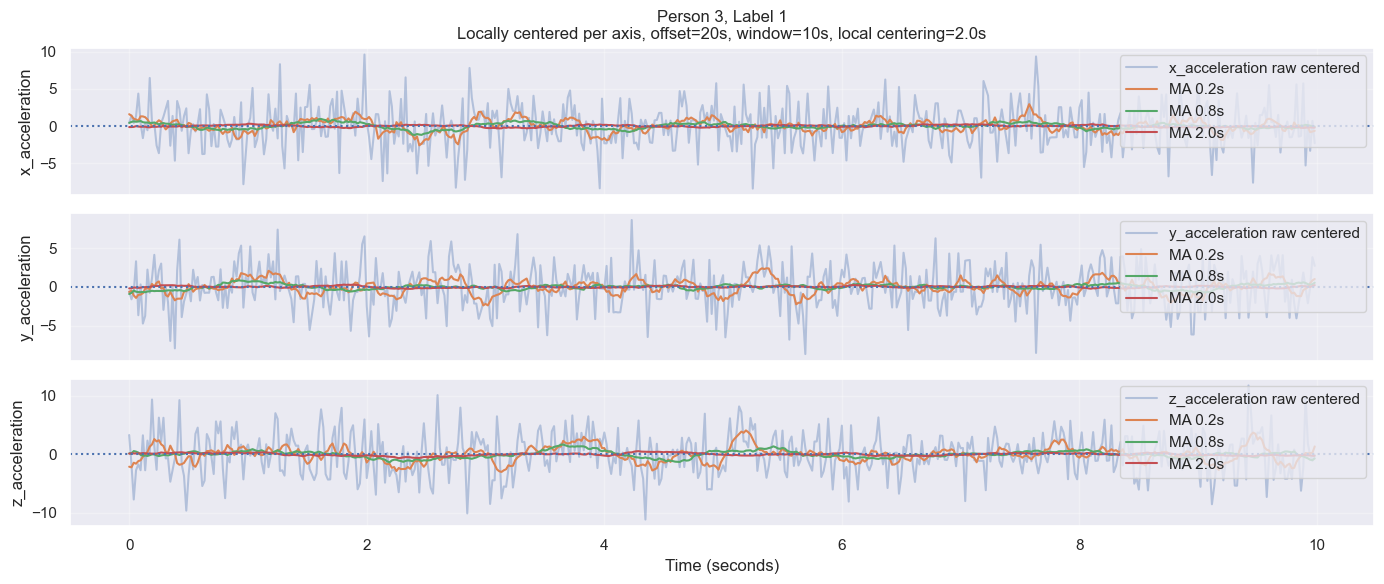

{'segment':       Sequence  x_acceleration  y_acceleration  z_acceleration  Labels
 1040    1040.0            1911            2367            1915       1
 1041    1041.0            1912            2366            1910       1
 1042    1042.0            1911            2367            1904       1
 1043    1043.0            1912            2371            1909       1
 1044    1044.0            1915            2364            1910       1
 1045    1045.0            1911            2368            1909       1
 1046    1046.0            1909            2363            1915       1
 1047    1047.0            1911            2364            1909       1
 1048    1048.0            1910            2370            1914       1
 1049    1049.0            1917            2367            1912       1
 1050    1050.0            1911            2369            1921       1
 1051    1051.0            1911            2372            1913       1
 1052    1052.0            1908            2368      

In [23]:
plot_xyz_with_multiple_smoothing(
    person_id=3,
    label=4,
    offset_seconds=20,
    window_seconds=10,
    local_center_window_seconds=2.0,
    smoothing_seconds=(0.2, 0.8, 2.0)
)
plot_xyz_with_multiple_smoothing(
    person_id=3,
    label=1,
    offset_seconds=20,
    window_seconds=10,
    local_center_window_seconds=2.0,
    smoothing_seconds=(0.2, 0.8, 2.0)
)

In [24]:

def compare_windowing_methods(
    person_id,
    label=None,
    offset_seconds=0,
    total_seconds=30,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    axis_center_window_samples=104,
    motion_center_window_samples=104,
    static_window_seconds=5,
    sliding_window_seconds=5,
    sliding_step_seconds=2.5,
    dynamic_smooth_samples=15,
    dynamic_threshold_quantile=0.70,
    dynamic_min_window_seconds=2.0,
    dynamic_merge_gap_seconds=0.5,
    figsize=(15, 10)
):
    

    file_path = f"{base_path}/{person_id}.csv"

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    if label is not None:
        df = df[df["Labels"] == label].copy()

    df = df.reset_index(drop=True)

    start = int(offset_seconds * fs)
    total_n = int(total_seconds * fs)
    end = start + total_n

    if end > len(df):
        print("Requested segment exceeds available data.")
        return None

    segment = df.iloc[start:end].copy()
    xyz = segment[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float)

    # Local centering of axes
    axis_n = max(3, int(axis_center_window_samples))
    axis_mean = xyz.rolling(window=axis_n, center=True, min_periods=1).mean()
    xyz_centered = xyz - axis_mean

    # Motion magnitude
    motion = np.sqrt((xyz_centered ** 2).sum(axis=1))

    # Zero-center motion itself
    motion_n = max(3, int(motion_center_window_samples))
    motion_baseline = pd.Series(motion).rolling(
        window=motion_n,
        center=True,
        min_periods=1
    ).mean()
    motion_zero = (motion - motion_baseline).to_numpy()

    t = np.arange(len(segment)) / fs

    # Static windows
    static_n = int(static_window_seconds * fs)
    static_intervals = []
    for s in range(0, len(segment) - static_n + 1, static_n):
        static_intervals.append((s / fs, (s + static_n) / fs))

    # Sliding windows
    sliding_n = int(sliding_window_seconds * fs)
    sliding_step_n = int(sliding_step_seconds * fs)
    sliding_intervals = []
    for s in range(0, len(segment) - sliding_n + 1, sliding_step_n):
        sliding_intervals.append((s / fs, (s + sliding_n) / fs))

    # Dynamic windows from motion
    dyn_smooth_n = max(3, int(dynamic_smooth_samples))
    motion_smooth = pd.Series(motion_zero).rolling(
        window=dyn_smooth_n,
        center=True,
        min_periods=1
    ).mean().to_numpy()

    activity_envelope = np.abs(motion_smooth)
    threshold = np.quantile(activity_envelope, dynamic_threshold_quantile)
    active = activity_envelope > threshold

    # Consecutive active runs
    dynamic_intervals = []
    i = 0
    while i < len(active):
        if active[i]:
            j = i
            while j < len(active) and active[j]:
                j += 1
            dynamic_intervals.append((i, j))
            i = j
        else:
            i += 1

    # Keep only sufficiently long intervals
    min_dyn_n = int(dynamic_min_window_seconds * fs)
    dynamic_intervals = [
        (s, e) for s, e in dynamic_intervals
        if (e - s) >= min_dyn_n
    ]

    # Merge nearby intervals
    merge_gap_n = int(dynamic_merge_gap_seconds * fs)
    merged_dynamic = []
    for s, e in dynamic_intervals:
        if not merged_dynamic:
            merged_dynamic.append([s, e])
        else:
            prev_s, prev_e = merged_dynamic[-1]
            if s - prev_e <= merge_gap_n:
                merged_dynamic[-1][1] = e
            else:
                merged_dynamic.append([s, e])

    dynamic_intervals = [(s / fs, e / fs) for s, e in merged_dynamic]

    # Plot
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)

    title = f"Person {person_id}"
    if label is not None:
        title += f", Label {label}"
    title += f" | offset={offset_seconds}s, total={total_seconds}s"

    # 1. Raw comparison signal
    axes[0].plot(t, motion_zero, label="zero-centered motion", alpha=0.45)
    axes[0].plot(t, motion_smooth, label="smoothed motion", linewidth=2)
    axes[0].axhline(0, linestyle=":")
    axes[0].set_ylabel("Motion")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 2. Static windows
    axes[1].plot(t, motion_zero, color="C0", alpha=0.6)
    for a, b in static_intervals:
        axes[1].axvspan(a, b, alpha=0.18, color="C1")
    axes[1].set_ylabel("Motion")
    axes[1].set_title(f"Static windows ({static_window_seconds}s, no overlap)")
    axes[1].grid(True, alpha=0.3)

    # 3. Sliding windows
    axes[2].plot(t, motion_zero, color="C0", alpha=0.6)
    for a, b in sliding_intervals:
        axes[2].axvspan(a, b, alpha=0.12, color="C2")
    axes[2].set_ylabel("Motion")
    axes[2].set_title(
        f"Sliding windows ({sliding_window_seconds}s, step={sliding_step_seconds}s)"
    )
    axes[2].grid(True, alpha=0.3)

    # 4. Dynamic windows
    axes[3].plot(t, motion_zero, color="C0", alpha=0.45, label="zero-centered motion")
    axes[3].plot(t, activity_envelope, color="C3", alpha=0.9, label="abs(smoothed motion)")
    axes[3].axhline(threshold, linestyle=":", color="C3", label="dynamic threshold")
    for a, b in dynamic_intervals:
        axes[3].axvspan(a, b, alpha=0.20, color="C4")
    axes[3].set_ylabel("Motion")
    axes[3].set_xlabel("Time (seconds)")
    axes[3].set_title("Dynamic windows from motion envelope")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    return {
        "segment": segment,
        "time": t,
        "motion_zero": motion_zero,
        "motion_smooth": motion_smooth,
        "activity_envelope": activity_envelope,
        "dynamic_threshold": threshold,
        "static_intervals": static_intervals,
        "sliding_intervals": sliding_intervals,
        "dynamic_intervals": dynamic_intervals,
    }

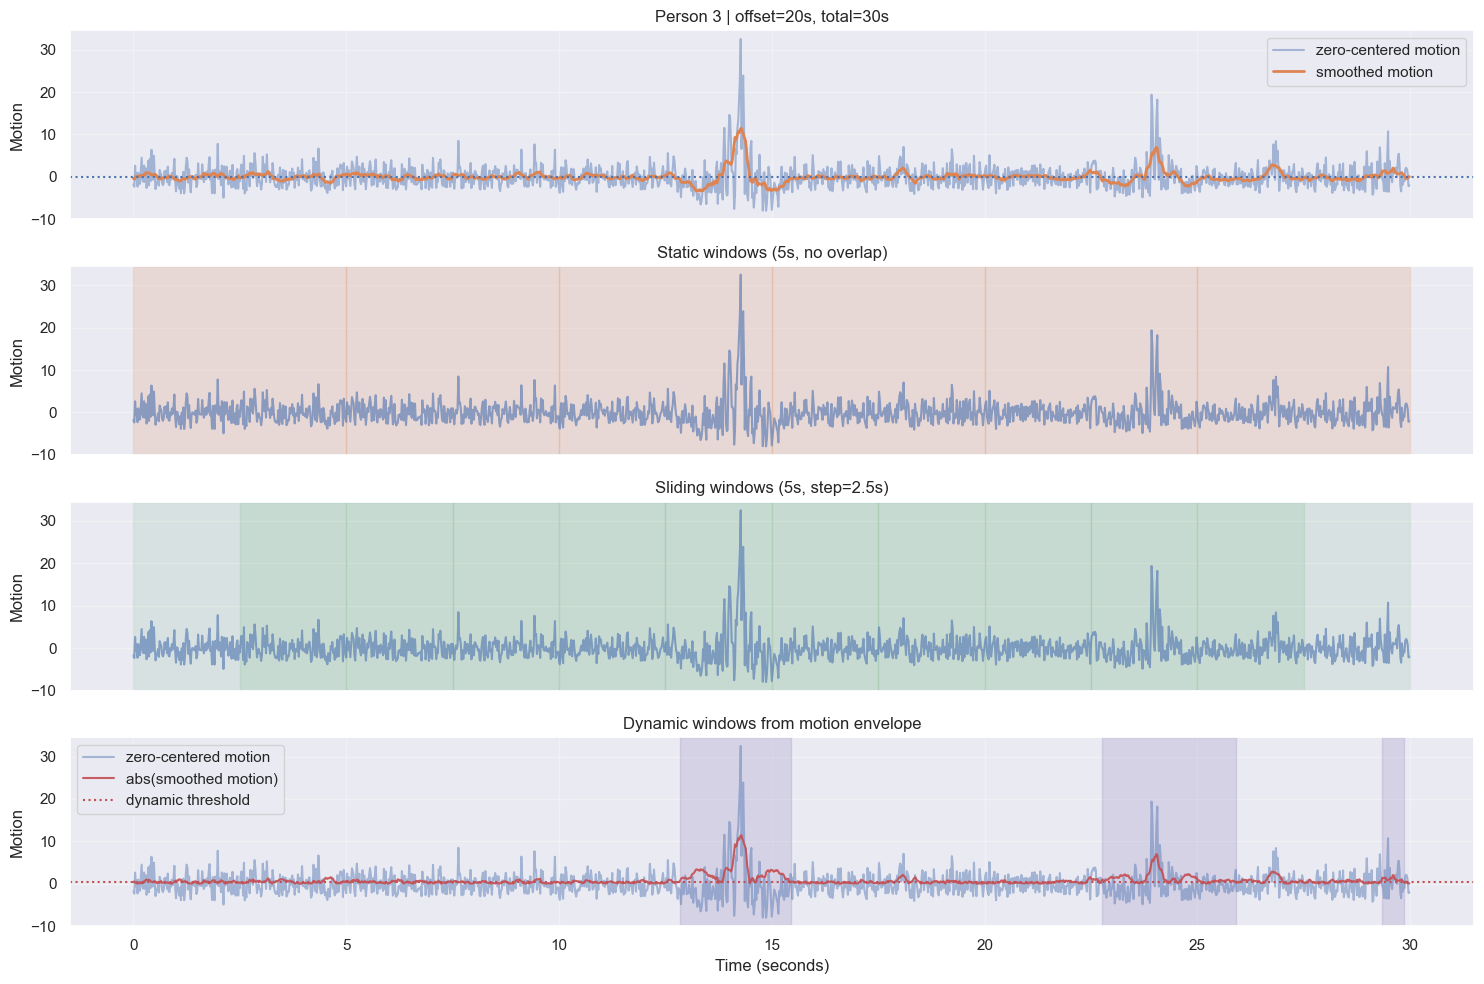

In [25]:
out = compare_windowing_methods(
    person_id=3,
    label=None,
    offset_seconds=20,
    total_seconds=30,
    static_window_seconds=5,
    sliding_window_seconds=5,
    sliding_step_seconds=2.5,
    dynamic_smooth_samples=15,
    dynamic_threshold_quantile=0.50,
    dynamic_min_window_seconds=0.5,
    dynamic_merge_gap_seconds=0.5
)

In [26]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

label_names = {
    1: "Working at Computer",
    2: "Standing Up, Walking, Going Up/Down Stairs",
    3: "Standing",
    4: "Walking",
    5: "Going Up/Down Stairs",
    6: "Walking and Talking with Someone",
    7: "Talking while Standing"
}

def zero_crossing_rate(signal):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 2:
        return 0.0

    signs = np.sign(signal).copy()

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]

    if signs[0] == 0:
        nz = np.nonzero(signs)[0]
        if len(nz) == 0:
            return 0.0
        signs[0] = signs[nz[0]]

    crossings = np.sum(signs[1:] != signs[:-1])
    return crossings / (len(signal) - 1)


def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) < 2 or len(b) < 2:
        return np.nan

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def compute_motion_signal(x, y, z):
    """
    Build zero-centered motion signal from window-wise mean-centered x, y, z.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    x_c = x - x.mean()
    y_c = y - y.mean()
    z_c = z - z.mean()

    motion = np.sqrt(x_c**2 + y_c**2 + z_c**2)
    motion_zero = motion - motion.mean()

    return motion_zero


def compute_motion_spectral_features(x, y, z, fs=52, step_band=(0.5, 3.0)):
    """
    Compute spectral energy and dominant step frequency from the zero-centered motion signal.
    """
    motion_zero = compute_motion_signal(x, y, z)

    if len(motion_zero) < 2:
        return 0.0, np.nan

    fft_vals = np.fft.rfft(motion_zero)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(len(motion_zero), d=1 / fs)

    non_dc_mask = freqs > 0
    spectral_energy = float(power[non_dc_mask].sum())

    band_mask = (freqs >= step_band[0]) & (freqs <= step_band[1])

    if np.any(band_mask):
        band_power = power[band_mask]
        band_freqs = freqs[band_mask]

        if np.all(band_power == 0):
            step_freq = np.nan
        else:
            step_freq = float(band_freqs[np.argmax(band_power)])
    else:
        step_freq = np.nan

    return spectral_energy, step_freq


def extract_window_features_from_person(
    person_id,
    window_seconds,
    step_seconds=None,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=False,
    step_band=(0.5, 3.0)
):
    """
    Extract sliding-window features for one person.
    """
    if step_seconds is None:
        step_seconds = window_seconds / 2

    window_size = int(window_seconds * fs)
    step_size = int(step_seconds * fs)

    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    df = df.reset_index(drop=True)

    rows = []

    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        w = df.iloc[start:end].copy()

        labels = w["Labels"].to_numpy()
        unique_labels, counts = np.unique(labels, return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        is_pure = len(unique_labels) == 1

        if require_pure_label and not is_pure:
            continue

        x = w["x_acceleration"].to_numpy(dtype=float)
        y = w["y_acceleration"].to_numpy(dtype=float)
        z = w["z_acceleration"].to_numpy(dtype=float)

        motion_zero = compute_motion_signal(x, y, z)
        motion_zcr = zero_crossing_rate(motion_zero)

        spectral_energy, step_freq = compute_motion_spectral_features(
            x=x,
            y=y,
            z=z,
            fs=fs,
            step_band=step_band
        )

        row = {
            "person_id": person_id,
            "start_sample": start,
            "end_sample": end - 1,
            "start_time_sec": start / fs,
            "end_time_sec": (end - 1) / fs,
            "window_size_samples": window_size,
            "window_size_sec": window_seconds,
            "step_size_samples": step_size,
            "step_size_sec": step_seconds,
            "label_majority": int(majority_label),
            "label_name": label_names.get(int(majority_label), str(int(majority_label))),
            "is_pure_label": bool(is_pure),

            "x_mean": float(np.mean(x)),
            "y_mean": float(np.mean(y)),
            "z_mean": float(np.mean(z)),

            "x_var": float(np.var(x, ddof=0)),
            "y_var": float(np.var(y, ddof=0)),
            "z_var": float(np.var(z, ddof=0)),

            "x_std": float(np.std(x, ddof=0)),
            "y_std": float(np.std(y, ddof=0)),
            "z_std": float(np.std(z, ddof=0)),

            "motion_zcr": float(motion_zcr),
            "spectral_energy": spectral_energy,
            "step_freq": step_freq,

            "xy_corr": safe_corr(x, y),
            "xz_corr": safe_corr(x, z),
            "yz_corr": safe_corr(y, z),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def extract_window_features_all_people(
    person_ids,
    window_seconds,
    step_seconds=None,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=False,
    step_band=(0.5, 3.0)
):
    """
    Extract sliding-window features for multiple people and combine into one dataframe.
    """
    all_dfs = []

    for person_id in person_ids:
        person_features = extract_window_features_from_person(
            person_id=person_id,
            window_seconds=window_seconds,
            step_seconds=step_seconds,
            fs=fs,
            base_path=base_path,
            drop_label_0=drop_label_0,
            require_pure_label=require_pure_label,
            step_band=step_band
        )
        all_dfs.append(person_features)

    if not all_dfs:
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)


def plot_feature_comparison(
    windows_df,
    labels=(3, 4, 5),
    colors=("tab:blue", "tab:orange", "tab:green"),
    mean_axis="x_mean",
    zcr_col="motion_zcr",
    energy_col="spectral_energy",
    label_name_col="label_name",
    label_col="label_majority",
    bins=40,
    alpha=0.5,
    figsize=(14, 4)
):
    """
    Compare 3 labels on mean, motion ZCR, and spectral energy.
    """

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    plot_specs = [
        (mean_axis, f"Distribution of {mean_axis}"),
        (zcr_col, f"Distribution of {zcr_col}"),
        (energy_col, f"Distribution of {energy_col}")
    ]

    for ax, (feature_col, title) in zip(axes, plot_specs):
        for label, color in zip(labels, colors):
            sub = windows_df[windows_df[label_col] == label]
            if sub.empty:
                print(f"No rows found for label {label}")
                continue

            label_name = sub[label_name_col].iloc[0] if label_name_col in sub.columns else str(label)

            ax.hist(
                sub[feature_col].dropna(),
                bins=bins,
                alpha=alpha,
                color=color,
                label=f"{label}: {label_name}",
                density=True
            )

        ax.set_title(title)
        ax.set_xlabel(feature_col)
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [27]:
windows_df = extract_window_features_all_people(
    person_ids=range(1, 16),
    window_seconds=5,
    step_seconds=2.5,
    require_pure_label=True
)

print(windows_df.head())
print(windows_df[[
    "motion_zcr", "spectral_energy", "step_freq",
    "xy_corr", "xz_corr", "yz_corr"
]].describe())

   person_id  start_sample  end_sample  start_time_sec  end_time_sec  \
0          1             0         259             0.0      4.980769   
1          1           130         389             2.5      7.480769   
2          1           260         519             5.0      9.980769   
3          1           390         649             7.5     12.480769   
4          1           520         779            10.0     14.980769   

   window_size_samples  window_size_sec  step_size_samples  step_size_sec  \
0                  260                5                130            2.5   
1                  260                5                130            2.5   
2                  260                5                130            2.5   
3                  260                5                130            2.5   
4                  260                5                130            2.5   

   label_majority           label_name  is_pure_label       x_mean  \
0               1  Working at Comp

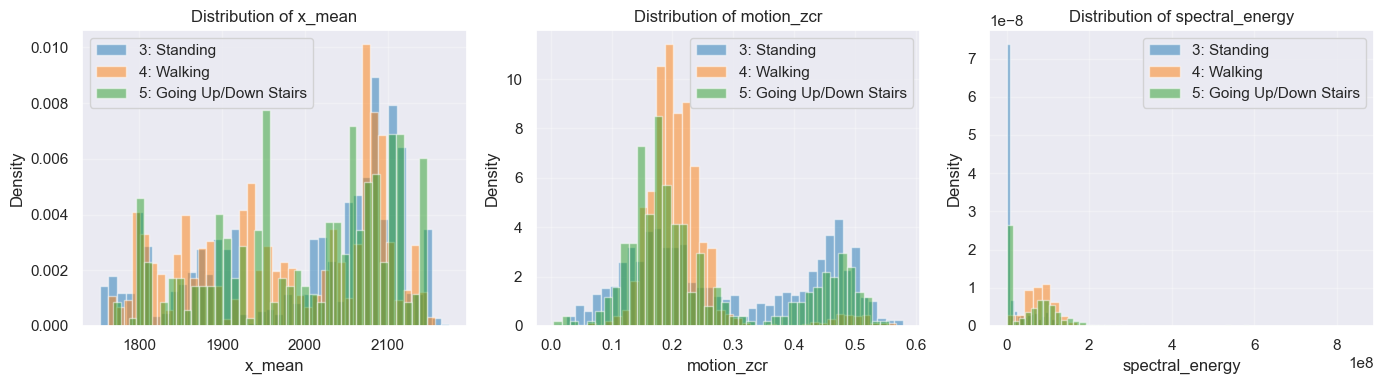

In [28]:
plot_feature_comparison(
    windows_df,
    labels=(3, 4, 5),
    colors=("tab:blue", "tab:orange", "tab:green"),
    mean_axis="x_mean",
    zcr_col="motion_zcr",
    energy_col="spectral_energy"
)

In [29]:
def build_training_dataframe(windows_df, drop_na=True):
    feature_cols = [
        "x_mean", "y_mean", "z_mean",
        "x_var", "y_var", "z_var",
        "x_std", "y_std", "z_std",
        "motion_zcr",
        "spectral_energy",
        "step_freq",
        "xy_corr", "xz_corr", "yz_corr"
    ]

    target_col = "label_majority"

    # Select only relevant columns
    Xy_df = windows_df[feature_cols + [target_col]].copy()

    # Optional: drop NaNs (important because of correlations / step_freq)
    if drop_na:
        before = len(Xy_df)
        Xy_df = Xy_df.dropna().reset_index(drop=True)
        after = len(Xy_df)
        print(f"Dropped {before - after} rows due to NaNs")

    return Xy_df

train_df = build_training_dataframe(windows_df)

print(train_df.head())
print(train_df.shape)

Dropped 0 rows due to NaNs
        x_mean       y_mean       z_mean         x_var         y_var  \
0  1833.961538  2209.157692  2024.107692  49456.529290  25969.125133   
1  1993.026923  2353.596154  2058.115385   9824.595429   3591.571524   
2  1958.342308  2375.534615  2105.184615   1147.748210   1039.364186   
3  1961.526923  2375.238462  2125.084615     69.387737     47.220059   
4  1961.126923  2377.550000  2115.880769     58.110814     29.178269   

          z_var       x_std       y_std       z_std  motion_zcr  \
0  25043.103787  222.388240  161.149388  158.250130    0.289575   
1  19918.348225   99.119097   59.929722  141.132378    0.166023   
2   3053.204379   33.878433   32.239172   55.255809    0.111969   
3    181.385148    8.329930    6.871685   13.467930    0.185328   
4    125.989630    7.623045    5.401691   11.224510    0.277992   

   spectral_energy  step_freq   xy_corr   xz_corr   yz_corr  label_majority  
0     2.261463e+08        0.6  0.702497 -0.059643  0.072548

In [30]:
Data = train_df.drop(columns=['label_majority']).values
target = train_df['label_majority'].values
print(Data.shape)
print(target.shape)


(14540, 15)
(14540,)


In [31]:
from sklearn import preprocessing

my_label = preprocessing.LabelEncoder()  
target = my_label.fit_transform(target)

# target=preprocessing.LabelEncoder().fit_transform(target)
print(np.unique(target))

[0 1 2 3 4 5 6]


In [32]:
from sklearn.model_selection import train_test_split

D_train8020, D_test8020, t_train8020, t_test8020 = train_test_split(Data, target, test_size=0.2, random_state=6758)
print(D_train8020.shape,D_test8020.shape,t_train8020.shape,t_test8020.shape)

D_train7030, D_test7030, t_train7030, t_test7030 = train_test_split(Data, target, test_size=0.3, random_state=6758)
print(D_train7030.shape,D_test7030.shape,t_train7030.shape,t_test7030.shape)

(11632, 15) (2908, 15) (11632,) (2908,)
(10178, 15) (4362, 15) (10178,) (4362,)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(D_train7030)

D_test7030=scaler.transform(D_test7030)
D_train7030=scaler.transform(D_train7030)

scaler.fit(D_train8020)

D_test8020=scaler.transform(D_test8020)
D_train8020=scaler.transform(D_train8020)

In [34]:
# Naive Bayes, Random Forest, AdaBoost, XGBoost (baseline fits)
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

data = [['8020', D_train8020, D_test8020, t_train8020, t_test8020], ['7030', D_train7030, D_test7030, t_train7030, t_test7030]]
classifiers = []
# fit on both splits
for split, D_train, D_test, t_train, t_test in data:
    svm_classifier = SVC(random_state=6758)
    svm_classifier.fit(D_train, t_train)

    dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=6578)
    dt_classifier.fit(D_train, t_train)

    nb_classifier = GaussianNB()
    nb_classifier.fit(D_train, t_train)

    rf_classifier = RandomForestClassifier(random_state=6758, n_jobs=-1)
    rf_classifier.fit(D_train, t_train)

    ada_classifier = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=6758),
        random_state=6758,
    )
    ada_classifier.fit(D_train, t_train)

    xgb_classifier = XGBClassifier(random_state=6758, n_jobs=-1, eval_metric='mlogloss')
    xgb_classifier.fit(D_train, t_train)
    classifiers.append([split, svm_classifier, dt_classifier, nb_classifier, rf_classifier, ada_classifier, xgb_classifier])


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [35]:
# Predicting
predictions = []
for split, svm_classifier, dt_classifier, nb_classifier, rf_classifier, ada_classifier, xgb_classifier in classifiers:
    print(f'======================= {split} split =======================')
    t_pred_svm = svm_classifier.predict(D_test)
    print('SVM Predicted accuracy score:', metrics.accuracy_score(t_test, t_pred_svm))

    t_pred_dt = dt_classifier.predict(D_test)
    print("DecisionTree accuracy score:", metrics.accuracy_score(t_test, t_pred_dt))

    t_pred_nb = nb_classifier.predict(D_test)
    print('Gaussian NB accuracy score:', metrics.accuracy_score(t_test, t_pred_nb))

    t_pred_rf = rf_classifier.predict(D_test)
    print('Random Forest accuracy score:', metrics.accuracy_score(t_test, t_pred_rf))

    t_pred_ada = ada_classifier.predict(D_test)
    print('AdaBoost accuracy score:', metrics.accuracy_score(t_test, t_pred_ada))

    t_pred_xgb = xgb_classifier.predict(D_test)
    print('XGBoost accuracy score:', metrics.accuracy_score(t_test, t_pred_xgb))
    predictions.append((split, t_pred_svm, t_pred_dt, t_pred_nb, t_pred_rf, t_pred_ada, t_pred_xgb))
    print('\n\n')

======================= 8020 split =======================
SVM Predicted accuracy score: 0.7336084364970197
DecisionTree accuracy score: 0.6570380559376433
Gaussian NB accuracy score: 0.47203117835855113
Random Forest accuracy score: 0.8530490600641908
AdaBoost accuracy score: 0.6233379183860615
XGBoost accuracy score: 0.8684089867033471



======================= 7030 split =======================
SVM Predicted accuracy score: 0.724438331040807
DecisionTree accuracy score: 0.6535992663915635
Gaussian NB accuracy score: 0.4731774415405777
Random Forest accuracy score: 0.8617606602475929
AdaBoost accuracy score: 0.6031636863823934
XGBoost accuracy score: 0.8913342503438789





======================= 8020 split =======================
======================= SVM =======================


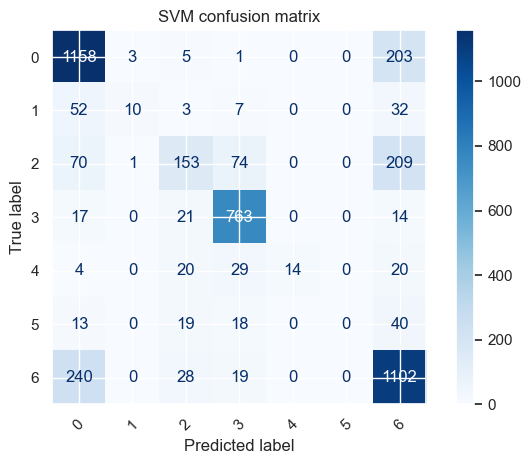

              precision    recall  f1-score   support

           0       0.75      0.85      0.79      1370
           1       0.71      0.10      0.17       104
           2       0.61      0.30      0.40       507
           3       0.84      0.94      0.88       815
           4       1.00      0.16      0.28        87
           5       0.00      0.00      0.00        90
           6       0.68      0.79      0.73      1389

    accuracy                           0.73      4362
   macro avg       0.66      0.45      0.47      4362
weighted avg       0.72      0.73      0.70      4362




======================= Decision Tree =======================


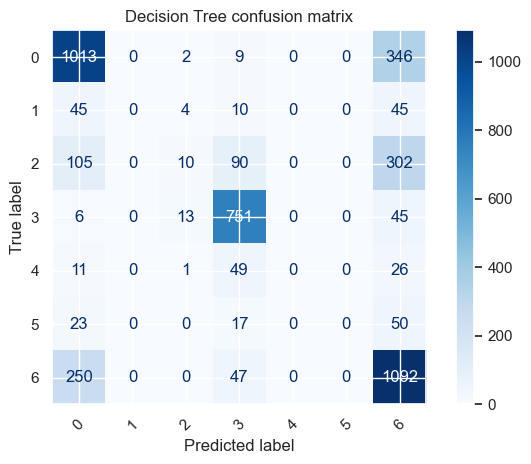

              precision    recall  f1-score   support

           0       0.70      0.74      0.72      1370
           1       0.00      0.00      0.00       104
           2       0.33      0.02      0.04       507
           3       0.77      0.92      0.84       815
           4       0.00      0.00      0.00        87
           5       0.00      0.00      0.00        90
           6       0.57      0.79      0.66      1389

    accuracy                           0.66      4362
   macro avg       0.34      0.35      0.32      4362
weighted avg       0.58      0.66      0.60      4362




======================= Gaussian NB =======================


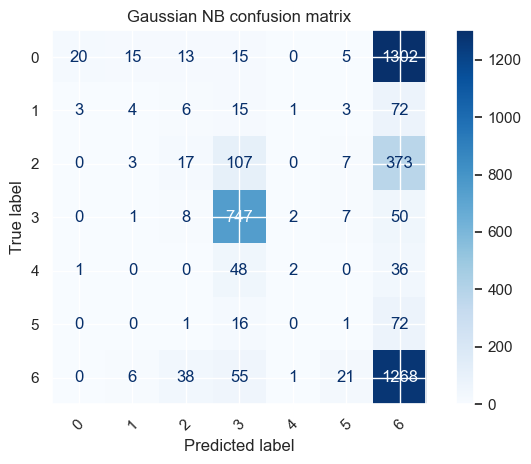

              precision    recall  f1-score   support

           0       0.83      0.01      0.03      1370
           1       0.14      0.04      0.06       104
           2       0.20      0.03      0.06       507
           3       0.74      0.92      0.82       815
           4       0.33      0.02      0.04        87
           5       0.02      0.01      0.01        90
           6       0.40      0.91      0.56      1389

    accuracy                           0.47      4362
   macro avg       0.38      0.28      0.23      4362
weighted avg       0.56      0.47      0.35      4362




======================= Random Forest =======================


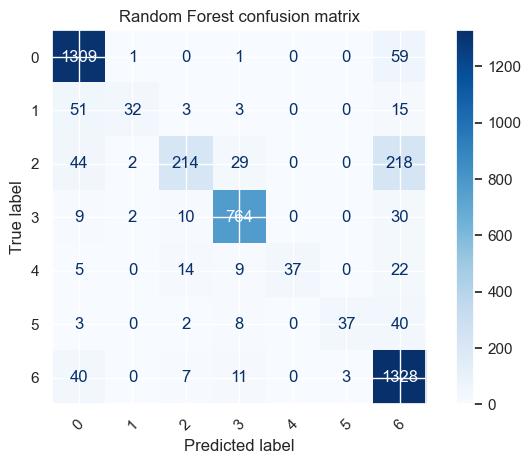

              precision    recall  f1-score   support

           0       0.90      0.96      0.92      1370
           1       0.86      0.31      0.45       104
           2       0.86      0.42      0.57       507
           3       0.93      0.94      0.93       815
           4       1.00      0.43      0.60        87
           5       0.93      0.41      0.57        90
           6       0.78      0.96      0.86      1389

    accuracy                           0.85      4362
   macro avg       0.89      0.63      0.70      4362
weighted avg       0.86      0.85      0.84      4362




======================= AdaBoost =======================


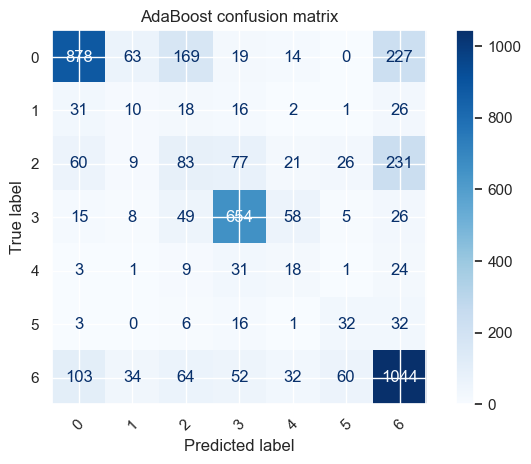

              precision    recall  f1-score   support

           0       0.80      0.64      0.71      1370
           1       0.08      0.10      0.09       104
           2       0.21      0.16      0.18       507
           3       0.76      0.80      0.78       815
           4       0.12      0.21      0.15        87
           5       0.26      0.36      0.30        90
           6       0.65      0.75      0.70      1389

    accuracy                           0.62      4362
   macro avg       0.41      0.43      0.42      4362
weighted avg       0.63      0.62      0.62      4362




======================= XGBoost =======================


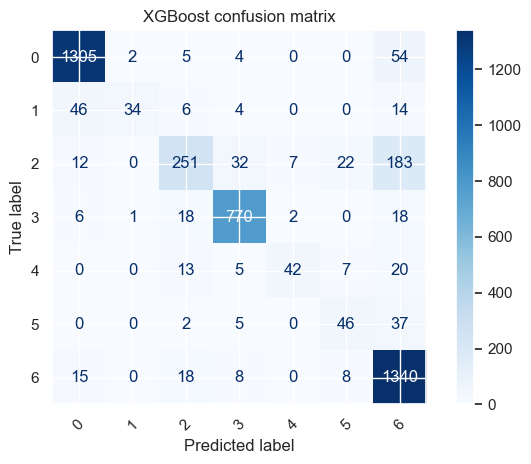

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1370
           1       0.92      0.33      0.48       104
           2       0.80      0.50      0.61       507
           3       0.93      0.94      0.94       815
           4       0.82      0.48      0.61        87
           5       0.55      0.51      0.53        90
           6       0.80      0.96      0.88      1389

    accuracy                           0.87      4362
   macro avg       0.83      0.67      0.71      4362
weighted avg       0.87      0.87      0.86      4362




======================= 7030 split =======================
======================= SVM =======================


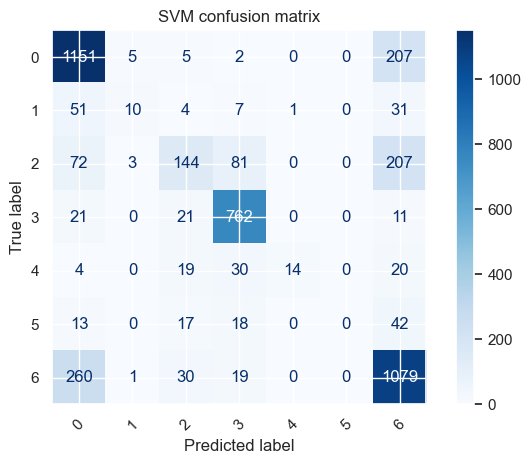

              precision    recall  f1-score   support

           0       0.73      0.84      0.78      1370
           1       0.53      0.10      0.16       104
           2       0.60      0.28      0.39       507
           3       0.83      0.93      0.88       815
           4       0.93      0.16      0.27        87
           5       0.00      0.00      0.00        90
           6       0.68      0.78      0.72      1389

    accuracy                           0.72      4362
   macro avg       0.61      0.44      0.46      4362
weighted avg       0.70      0.72      0.69      4362




======================= Decision Tree =======================


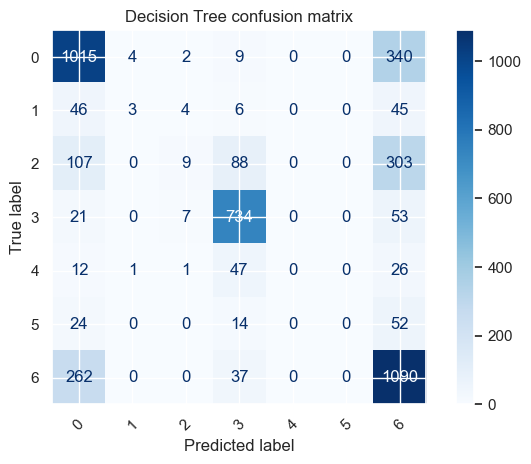

              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1370
           1       0.38      0.03      0.05       104
           2       0.39      0.02      0.03       507
           3       0.79      0.90      0.84       815
           4       0.00      0.00      0.00        87
           5       0.00      0.00      0.00        90
           6       0.57      0.78      0.66      1389

    accuracy                           0.65      4362
   macro avg       0.40      0.35      0.33      4362
weighted avg       0.60      0.65      0.60      4362




======================= Gaussian NB =======================


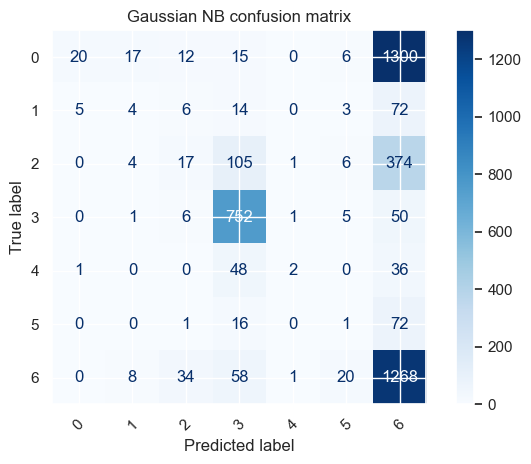

              precision    recall  f1-score   support

           0       0.77      0.01      0.03      1370
           1       0.12      0.04      0.06       104
           2       0.22      0.03      0.06       507
           3       0.75      0.92      0.83       815
           4       0.40      0.02      0.04        87
           5       0.02      0.01      0.02        90
           6       0.40      0.91      0.56      1389

    accuracy                           0.47      4362
   macro avg       0.38      0.28      0.23      4362
weighted avg       0.55      0.47      0.35      4362




======================= Random Forest =======================


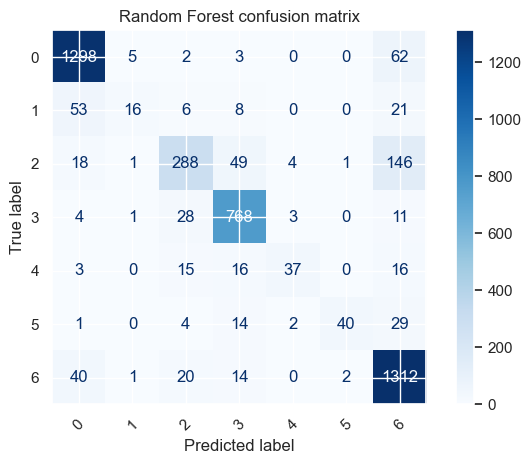

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1370
           1       0.67      0.15      0.25       104
           2       0.79      0.57      0.66       507
           3       0.88      0.94      0.91       815
           4       0.80      0.43      0.56        87
           5       0.93      0.44      0.60        90
           6       0.82      0.94      0.88      1389

    accuracy                           0.86      4362
   macro avg       0.83      0.63      0.68      4362
weighted avg       0.86      0.86      0.85      4362




======================= AdaBoost =======================


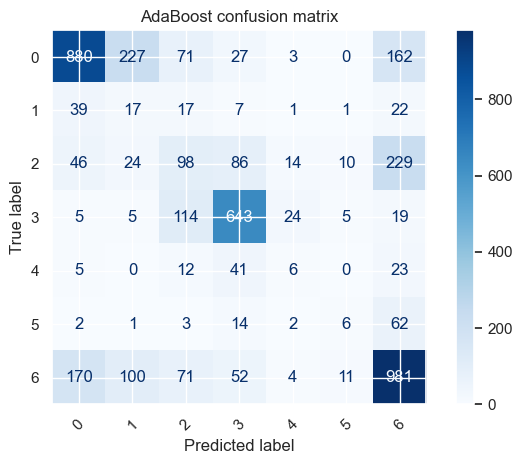

              precision    recall  f1-score   support

           0       0.77      0.64      0.70      1370
           1       0.05      0.16      0.07       104
           2       0.25      0.19      0.22       507
           3       0.74      0.79      0.76       815
           4       0.11      0.07      0.09        87
           5       0.18      0.07      0.10        90
           6       0.65      0.71      0.68      1389

    accuracy                           0.60      4362
   macro avg       0.39      0.38      0.37      4362
weighted avg       0.62      0.60      0.61      4362




======================= XGBoost =======================


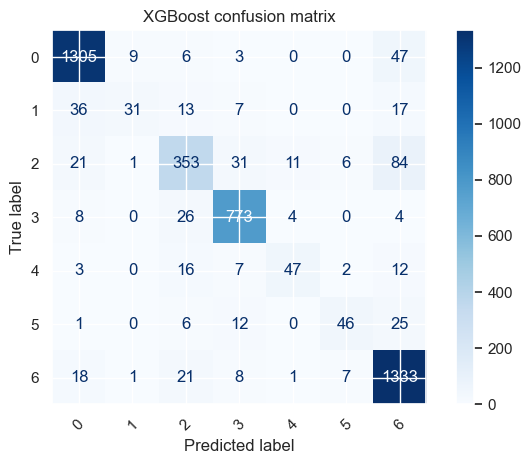

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1370
           1       0.74      0.30      0.42       104
           2       0.80      0.70      0.74       507
           3       0.92      0.95      0.93       815
           4       0.75      0.54      0.63        87
           5       0.75      0.51      0.61        90
           6       0.88      0.96      0.92      1389

    accuracy                           0.89      4362
   macro avg       0.82      0.70      0.74      4362
weighted avg       0.89      0.89      0.88      4362






In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

for split, t_pred_svm, t_pred_dt, t_pred_nb, t_pred_rf, t_pred_ada, t_pred_xgb in predictions:
    print(f'======================= {split} split =======================')
    for model_name, y_pred in [
        ('SVM', t_pred_svm),
        ('Decision Tree', t_pred_dt),
        ('Gaussian NB', t_pred_nb),
        ('Random Forest', t_pred_rf),
        ('AdaBoost', t_pred_ada),
        ('XGBoost', t_pred_xgb),
    ]:
        print(f'======================= {model_name} =======================')

        ConfusionMatrixDisplay.from_predictions(
            t_test,
            y_pred,
            cmap="Blues",
            xticks_rotation=45,
        )
        plt.title(model_name + ' confusion matrix')
        plt.tight_layout()
        plt.show()
        print(metrics.classification_report(t_test, y_pred))
        print('\n\n')

# ANN (MLP) 

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

num_features = D_train8020.shape[1]
num_classes = len(np.unique(target))

def build_mlp(num_features, num_classes):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True,
)

mlp_model = build_mlp(num_features, num_classes)
mlp_model.summary()

history = mlp_model.fit(
    D_train7030, t_train7030,
    validation_data=(D_test7030, t_test7030),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,615 (49.28 KB)

 Trainable params: 12,615 (49.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.5009 - loss: 1.4131 - val_accuracy: 0.6371 - val_loss: 1.0437
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.6262 - loss: 1.0930 - val_accuracy: 0.6735 - val_loss: 0.9507
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.6522 - loss: 1.0398 - val_accuracy: 0.7121 - val_loss: 0.8830
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.6810 - loss: 0.9494 - val_accuracy: 0.7295 - val_loss: 0.8267
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - accuracy: 0.6924 - loss: 0.9116 - val_accuracy: 0.7501 - val_loss: 0.7898
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.7017 - loss: 0.8827 - val_accuracy: 0.7538 - val_loss: 0.7560
Epoch 7/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.7109 - loss: 0.8554 - val_accuracy: 0.7620 - val_loss: 0.7328
Epoch 8/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.7285 - loss: 0

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step
MLP accuracy score: 0.8392939018798716

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1370
           1       0.67      0.15      0.25       104
           2       0.64      0.54      0.59       507
           3       0.90      0.91      0.91       815
           4       0.74      0.36      0.48        87
           5       0.72      0.23      0.35        90
           6       0.80      0.94      0.86      1389

    accuracy                           0.84      4362
   macro avg       0.77      0.58      0.62      4362
weighted avg       0.83      0.84      0.83      4362



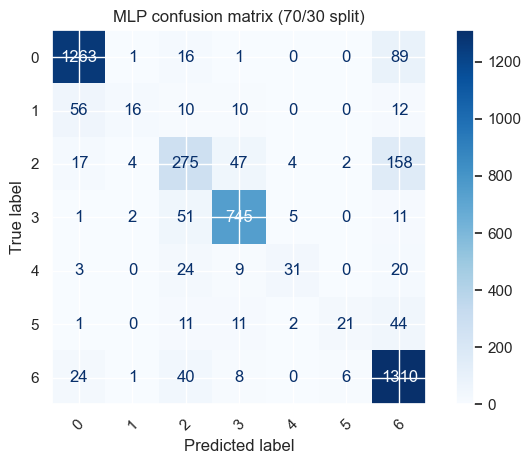

In [38]:
t_pred_mlp = np.argmax(mlp_model.predict(D_test7030), axis=1)

print('MLP accuracy score:', metrics.accuracy_score(t_test7030, t_pred_mlp))
print()
print(metrics.classification_report(t_test7030, t_pred_mlp))

ConfusionMatrixDisplay.from_predictions(
    t_test7030,
    t_pred_mlp,
    cmap="Blues",
    xticks_rotation=45,
)
plt.title('MLP confusion matrix (70/30 split)')
plt.tight_layout()
plt.show()

# 1-D Convolutional Neural Network (CNN) 


In [42]:
def extract_raw_windows_from_person(
    person_id,
    window_seconds=5,
    step_seconds=None,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=False,
):
    """
    Extract raw accelerometer windows for one person.
    Returns (windows, labels) where windows is a list of (window_size, 3) arrays.
    Uses the same windowing logic as extract_window_features_from_person.
    """
    if step_seconds is None:
        step_seconds = window_seconds / 2

    window_size = int(window_seconds * fs)
    step_size = int(step_seconds * fs)

    file_path = os.path.join(base_path, f"{person_id}.csv")
    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"],
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()
    df = df.reset_index(drop=True)

    windows = []
    labels = []

    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        w = df.iloc[start:end]

        window_labels = w["Labels"].to_numpy()
        unique_labels, counts = np.unique(window_labels, return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        is_pure = len(unique_labels) == 1

        if require_pure_label and not is_pure:
            continue

        x = w["x_acceleration"].to_numpy(dtype=float)
        y = w["y_acceleration"].to_numpy(dtype=float)
        z = w["z_acceleration"].to_numpy(dtype=float)

        windows.append(np.column_stack([x, y, z]))
        labels.append(int(majority_label))

    return windows, labels


def extract_raw_windows_all_people(
    person_ids,
    window_seconds=5,
    step_seconds=None,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=False,
):
    all_windows = []
    all_labels = []
    for pid in person_ids:
        w, l = extract_raw_windows_from_person(
            pid,
            window_seconds=window_seconds,
            step_seconds=step_seconds,
            fs=fs,
            base_path=base_path,
            drop_label_0=drop_label_0,
            require_pure_label=require_pure_label,
        )
        all_windows.extend(w)
        all_labels.extend(l)
    return np.array(all_windows), np.array(all_labels)


raw_windows, raw_labels = extract_raw_windows_all_people(
    person_ids=range(1, 16),
    window_seconds=5,
    step_seconds=2.5,
    require_pure_label=True,
)

raw_labels_encoded = preprocessing.LabelEncoder().fit_transform(raw_labels)
num_classes_cnn = len(np.unique(raw_labels_encoded))

print(f"Raw windows shape: {raw_windows.shape}")
print(f"Labels shape: {raw_labels_encoded.shape}")
print(f"Num classes: {num_classes_cnn}")

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    raw_windows, raw_labels_encoded, test_size=0.3, random_state=42,
)

train_mean = X_train_cnn.mean(axis=(0, 1))
train_std  = X_train_cnn.std(axis=(0, 1))
X_train_cnn = (X_train_cnn - train_mean) / train_std
X_test_cnn  = (X_test_cnn  - train_mean) / train_std

print(f"\nTrain shape: {X_train_cnn.shape}")
print(f"Test  shape: {X_test_cnn.shape}")

Raw windows shape: (14540, 260, 3)
Labels shape: (14540,)
Num classes: 7

Train shape: (10178, 260, 3)
Test  shape: (4362, 260, 3)


In [40]:
from tensorflow.keras import layers, models, callbacks

def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

cnn_model = build_cnn(
    input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2]),
    num_classes=num_classes_cnn,
)
cnn_model.summary()

early_stop_cnn = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True,
)

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_test_cnn, y_test_cnn),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn],
    verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 260, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 260, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 130, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 130, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 130, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 65, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,383 (396.03 KB)

 Trainable params: 100,743 (393.53 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6090 - loss: 1.1928 - val_accuracy: 0.6829 - val_loss: 0.9314
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7116 - loss: 0.8763 - val_accuracy: 0.7712 - val_loss: 0.6755
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7284 - loss: 0.8245 - val_accuracy: 0.7710 - val_loss: 0.6683
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7425 - loss: 0.7686 - val_accuracy: 0.7721 - val_loss: 0.6471
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7532 - loss: 0.7414 - val_accuracy: 0.7545 - val_loss: 0.6934
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7646 - loss: 0.7111 - val_accuracy: 0.7928 - val_loss: 0.6116
Epoch 7/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7689 - loss: 0.7039 - val_accuracy: 0.8012 - val_loss: 0.5790
Epoch 8/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7564 - loss: 0.7141 - 

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN accuracy score: 0.8837689133425034

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1391
           1       0.79      0.32      0.46       115
           2       0.66      0.72      0.69       446
           3       0.95      0.93      0.94       828
           4       0.93      0.51      0.66       111
           5       0.94      0.32      0.48       102
           6       0.88      0.94      0.91      1369

    accuracy                           0.88      4362
   macro avg       0.87      0.67      0.73      4362
weighted avg       0.89      0.88      0.88      4362



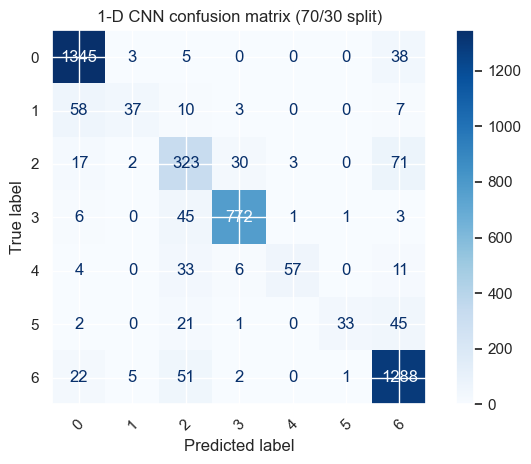

In [43]:
t_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

print('CNN accuracy score:', metrics.accuracy_score(y_test_cnn, t_pred_cnn))
print()
print(metrics.classification_report(y_test_cnn, t_pred_cnn))

ConfusionMatrixDisplay.from_predictions(
    y_test_cnn,
    t_pred_cnn,
    cmap="Blues",
    xticks_rotation=45,
)
plt.title('1-D CNN confusion matrix (70/30 split)')
plt.tight_layout()
plt.show()

In [ ]:
## 3.5 Simple RNN (Elman Network) with TensorFlow

In [53]:
def build_rnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.SimpleRNN(64, return_sequences=True),
        layers.Dropout(0.3),

        layers.SimpleRNN(32, return_sequences=False),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

rnn_model = build_rnn(
    input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2]),
    num_classes=num_classes_cnn,
)
rnn_model.summary()

early_stop_rnn = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True,
)

rnn_history = rnn_model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_test_cnn, y_test_cnn),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_rnn],
    verbose=1,
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_13 (SimpleRNN)       │ (None, 260, 64)        │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 260, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,023 (39.15 KB)

 Trainable params: 10,023 (39.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3835 - loss: 1.5914 - val_accuracy: 0.5697 - val_loss: 1.2484
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5177 - loss: 1.3274 - val_accuracy: 0.4927 - val_loss: 1.3218
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5418 - loss: 1.2952 - val_accuracy: 0.5044 - val_loss: 1.3207
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5558 - loss: 1.2584 - val_accuracy: 0.5993 - val_loss: 1.1658
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5988 - loss: 1.1948 - val_accuracy: 0.6320 - val_loss: 1.1335
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4963 - loss: 1.3618 - val_accuracy: 0.4961 - val_loss: 1.3718
Epoch 7/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4276 - loss: 1.5019 - val_accuracy: 0.4548 - val_loss: 1.4140
Epoch 8/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4447 - loss: 1.4037 -

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Simple RNN accuracy score: 0.6320495185694636

              precision    recall  f1-score   support

           0       0.66      0.82      0.73      1391
           1       0.00      0.00      0.00       115
           2       0.00      0.00      0.00       446
           3       0.72      0.75      0.73       828
           4       0.00      0.00      0.00       111
           5       0.00      0.00      0.00       102
           6       0.56      0.73      0.64      1369

    accuracy                           0.63      4362
   macro avg       0.28      0.33      0.30      4362
weighted avg       0.52      0.63      0.57      4362



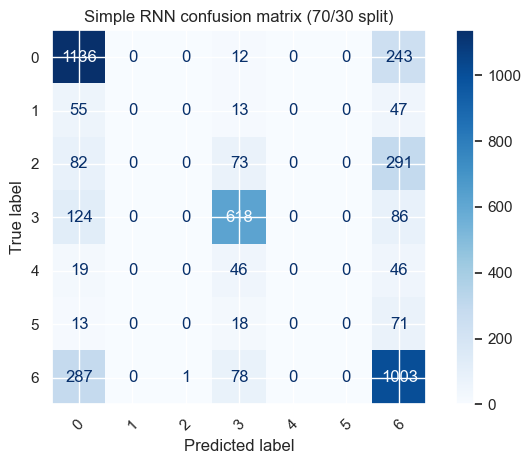

In [54]:
t_pred_rnn = np.argmax(rnn_model.predict(X_test_cnn), axis=1)

print('Simple RNN accuracy score:', metrics.accuracy_score(y_test_cnn, t_pred_rnn))
print()
print(metrics.classification_report(y_test_cnn, t_pred_rnn))

ConfusionMatrixDisplay.from_predictions(
    y_test_cnn,
    t_pred_rnn,
    cmap="Blues",
    xticks_rotation=45,
)
plt.title('Simple RNN confusion matrix (70/30 split)')
plt.tight_layout()
plt.show()